In [ ]:
import pandas as pd
import numpy as np

import itertools
import math
import matplotlib.pyplot as plt
import seaborn as sns

import graph_tool.all as gt
import copy

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colorbar import ColorbarBase

from itertools import combinations
from scipy.stats import entropy

import os
import pickle
import gzip
from pathlib import Path

from survey_sbm import * 

In [2]:
Data = pd.read_stata("/Users/zhina/Downloads/BES2024_W30_Panel_v30.1.dta")
Data

,id,waves_taken,wave1,wave2,wave3,wave4,wave5,wave6,wave7,wave8,...,p_eurefturnout,new_pcon_yougovW26,new_pcon_yougovW27,new_pcon_yougovW28,new_pcon_yougovW29,big_five_agreeableness,big_five_conscientiousness,big_five_extraversion,big_five_neuroticism,big_five_openness
0,1,9.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,"Yes, voted",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,21.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,"Yes, voted",NaN,197.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,16.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,"Yes, voted",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122377,123795,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,"No, did not vote",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
122378,123796,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,"No, did not vote",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
122379,123797,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,"No, did not vote",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
122380,123798,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,"No, did not vote",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
core_demographics = [
    "gender", # Respondent gender (male/female)
    "p_edlevel", # Highest level of education
    "p_work_stat", # Employment status (full-time, part-time, student, unemployed, etc.)
    "p_gross_household", # Total household income (banded categories)
    "p_ethnicity", # Ethnic group of respondent
    "p_religion", # Religious affiliation
    "p_sexuality", # Sexual orientation
    "subjClass" # class you think you belong
    "generalElectionVote", # Which party did you vote for
    "partyId", # Which party do you belong to?
    "partyIdStrength", # How strongly?
    "euRefVote" ]# Stay in European Union or leave?

In [4]:
Data.filter(like="trustMPs").columns

Index(['trustMPsW1', 'trustMPsW2', 'trustMPsW3', 'trustMPsW4', 'trustMPsW6',
       'trustMPsW7', 'trustMPsW8', 'trustMPsW9', 'trustMPsW10', 'trustMPsW12',
       'trustMPsW15', 'trustMPsW16', 'trustMPsW17', 'trustMPsW18',
       'trustMPsW19', 'trustMPsW20', 'trustMPsW21', 'trustMPsW23',
       'trustMPsW25', 'trustMPsW26', 'trustMPsW27', 'trustMPsW28',
       'trustMPsW29', 'trustMPsW30'],
      dtype='object')

## 3 Waves W16-W20-W25

Wave 16 was conducted in June 2019. Wave 20 was conducted in June 2020. Wave 25 was conducted in May 2023.

## Questions:

- Political ideology:
    - leftRight : in politics people sometimes talk of left and right, where would you place yourself? (0–10) (W1W2W3W4W5W6W7W8W9W10W11W12W13W14W15W16W17W18W19W20W21W22W23W24W25W26W27W28W29W30) 
    - turnoutUKGeneral: If there were a UK General Election tomorrow, how likely is it that you would vote? ((W15W16W20W21W22W23W25W26)) (1-5)
    - polAttention:  How much attention do you generally pay to politics? (W1W2W3W4W6W7W8W10W11W13W14W15W16W17W19W20W21W22W23W25W26W28W29) (1-10)

- Values Part1: (1–5) (W6 W13 W16 W20W21W22W23W24 W30) 
    - authorityRespect - al1: Young people today don’t have enough respect for traditional British values.
    - Death penalty - al2 : For some crimes, the death penalty is the most appropriate sentence.
    - obeyauthority - al3 : Schools should teach children to obey authority.
    - Censorship - al4: Censorship of films and magazines is necessary to uphold moral standards.
    - stiffer sentences - al5 : People who break the law should be given stiffer sentences.

- Values Part2 :  (W1W6W7W10W11W12W13W14W15W16W17W20W21W22W23W24W25W26W27W29) (1-5)
    - lr1: Government should redistribute income from the better off to those who are less well off.
    - lr2: Big business takes advantage of ordinary people. 
    - lr3 : Ordinary working people do not get their fair share of the nation’s wealth. 
    - lr4 : There is one law for the rich and one for the poor. 
    - lr5 :Management will always try to get the better of employees if it gets the chance.

- Immigration:
    - immigEcon: Do you think immigration is good or bad for Britain’s economy? (1-7) (W1W2W3W4 W7W8W10W11W13W14W15W16W17W20W21W22W23W24W25W26W27W30) 
    - immigCultural: Do you think that immigration undermines or enriches Britain’s cultural life?(1-7) (W1W2W3W4W7 W8W10W11W13W14W15W16W17 W20W24W27) 

- Environment:
    - enviroGrowth: Some believe that protecting the environment should have priority even if that reduces economic growth. What is your opinion? (W4W6W7W16W17W20W23W25W26W27W28W30)(0-10)

- Trust:
    - trustMPs: How much trust do you have in Members of Parliament in general? (1-7) (W1W2W3W4W5W6W7W8W9W10W11W12W13W14W15W16W17W18W19W20W21W22W23W24W25W26W27W28W29W30)

- Brexit:
    - EUIntegrationSelf: Some people feel that Britain should do all it can to unite fully with the European Union. Other people no . Where would you place yourself? W15W16W17W18W19W20W21W22W23W24W25W26W27W28W29

- Identity: (1-7) (W1W2W3W4W8W9W10W11W12W13W14W15W16W717W20W21W22W23W25W26W27W29)
    - britishness: Where would you place yourself on these scales? 
    - europeanness: Where would you place yourself on these scales?

- Income equality:
    - redistSelf: Some people feel that government should make much greater efforts to make people’s incomes more equal. What is your opinion? (W1W2W3W4W6W10W11W12W13W14W15W16W17W18W19WW7 20W21W22W23W24W25W26W27W29W30) (0-10)

In [5]:
W16_20_25 = Data[(Data['wave16']==1) & (Data['wave20']==1) & (Data['wave25']==1)]

print(len(W16_20_25), "Respondednts were present in all 3 waves.")

9618 Respondednts were present in all 3 waves.


To avoid computational complexity, we will only selece 4000 reposndets.

In [6]:
W16_20_25 = W16_20_25.sample(n=4000, random_state=123)

print(len(W16_20_25), "Respondednts were chosen randomly.")

4000 Respondednts were chosen randomly.


In [7]:
core_demographics = [
    "id", # Unique ID
    "gender", ]# Respondent gender (male/female)

In [8]:
base_questions = [
    'leftRight', # From Left to right where would you place yourself? (0–10)
    'turnoutUKGeneral', # how likely is it that you would vote? (1-5)
    'polAttention', # How much attention do you generally pay to politics?(0–10)
    
    'britishness', # Where would you place yourself on britishness scales? (1-7)
    'europeanness', # Where would you place yourself on europeanness scales? (1-7) 
    
    'trustMPs', # How much trust do you have in Members of Parliament in general? (1-7)
    
    'enviroGrowth', # protecting the environment should have priority or reducing economic growth? (0-10)
    
    'redistSelf', # Some people feel that government should make much greater efforts to make people’s incomes more equal. What is your opinion? (0-10)
    
    'immigEcon', # Do you think immigration is good or bad for Britain’s economy? (1-7)
   # 'immigCultural', # Do you think that immigration undermines or enriches Britain’s cultural life? (1-7)
    
    'EUIntegrationSelf',  # Brexit (0-10)
    
    'lr1', # Government should redistribute income from the better off to those who are less well off.(1–5)
    'lr2', # Big business takes advantage of ordinary people. (1–5)
    'lr3',  #Ordinary working people do not get their fair share of the nation’s wealth. (1–5)
    'lr4', # There is one law for the rich and one for the poor. (1–5)
    'lr5', # Management will always try to get the better of employees if it gets the chance. (1–5)

    'al1', # Young people today don’t have enough respect for traditional British values (1–5)
    'al2', # For some crimes, the death penalty is the most appropriate sentence (1–5)
    'al3', # Schools should teach children to obey authority (1–5)
    'al4', # Censorship of films and magazines is necessary to uphold moral standards (1–5)
    'al5' ] # People who break the law should be given stiffer sentences (1–5)  

waves = [16, 20, 25]

questions_by_wave = {}

for w in waves:
    if w == 25:
        questions_by_wave["W25"] = [
            f"{q}W25" if not (q.startswith(('lr', 'al'))) 
            else f"{q}W25W26"
            for q in base_questions
        ]
    else:
        questions_by_wave[f"W{w}"] = [f"{q}W{w}" for q in base_questions]
        
print(questions_by_wave['W25'])

['leftRightW25', 'turnoutUKGeneralW25', 'polAttentionW25', 'britishnessW25', 'europeannessW25', 'trustMPsW25', 'enviroGrowthW25', 'redistSelfW25', 'immigEconW25', 'EUIntegrationSelfW25', 'lr1W25W26', 'lr2W25W26', 'lr3W25W26', 'lr4W25W26', 'lr5W25W26', 'al1W25W26', 'al2W25W26', 'al3W25W26', 'al4W25W26', 'al5W25W26']


In [9]:
W16_20_25_selected_columns = W16_20_25[core_demographics + questions_by_wave["W16"] + questions_by_wave["W20"] + questions_by_wave["W25"]]
W16_20_25_selected_columns

,id,gender,leftRightW16,turnoutUKGeneralW16,polAttentionW16,britishnessW16,europeannessW16,trustMPsW16,enviroGrowthW16,redistSelfW16,...,lr1W25W26,lr2W25W26,lr3W25W26,lr4W25W26,lr5W25W26,al1W25W26,al2W25W26,al3W25W26,al4W25W26,al5W25W26
57955,58001,Female,7,Very likely that I would vote,7,Very strongly British,2,NaN,Protecting the environment should have priority,7,...,Neither agree nor disagree,Agree,Neither agree nor disagree,Disagree,Strongly agree,Strongly agree,Disagree,Strongly agree,Strongly agree,Strongly agree
12145,12146,Male,3,Very likely that I would vote,7,Very strongly British,6,NaN,9,3,...,Agree,Strongly agree,Agree,Agree,Agree,Disagree,Strongly disagree,Disagree,Strongly disagree,Disagree
62936,63015,Female,Don't know,Very likely that I would vote,4,6,5,NaN,7,6,...,Agree,Agree,Agree,Agree,Agree,Neither agree nor disagree,Strongly disagree,Neither agree nor disagree,Agree,Agree
61391,61456,Female,Right,Very likely that I would vote,5,Very strongly British,Very strongly European,NaN,Protecting the environment should have priority,Don't know,...,Agree,Agree,Agree,Agree,Agree,Strongly agree,Agree,Agree,Agree,Strongly agree
60406,60462,Male,Don't know,Very unlikely that I would vote,3,6,4,No trust,6,Don't know,...,Neither agree nor disagree,Agree,Agree,Agree,Agree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Agree
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54601,54607,Male,Don't know,Very unlikely that I would vote,Pay no attention,Don't know,Don't know,NaN,Don't know,Don't know,...,Agree,Strongly agree,Agree,Agree,Strongly agree,Neither agree nor disagree,Agree,Neither agree nor disagree,Don't know,Agree
87373,88787,Female,Don't know,Fairly likely,3,4,Don't know,Don't know,8,3,...,Agree,Agree,Agree,Strongly agree,Agree,Neither agree nor disagree,Don't know,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree
64816,64919,Female,5,Neither likely nor unlikely,5,4,4,4,5,Don't know,...,Don't know,Don't know,Don't know,Don't know,Don't know,Don't know,Don't know,Don't know,Don't know,Don't know
56266,56273,Male,2,Very likely that I would vote,8,6,4,NaN,5,1,...,Strongly agree,Agree,Strongly agree,Agree,Agree,Neither agree nor disagree,Strongly disagree,Agree,Agree,Disagree


In [10]:
mappings = {
    'leftRight': { 'Left': 0, 'Right': 10, "Don't know": 9999 },
    'britishness':  { 'Not at all British': 1, 'Very strongly British': 7, "Don't know": 9999 },
    'europeanness': { 'Not at all European': 1, 'Very strongly European': 7, "Don't know": 9999 },
    'enviroGrowth': {'Economic growth should have priority': 0, 'Protecting the environment should have priority': 10, "Don't know": 9999},
    'redistSelf': {'Government should try to make incomes equal': 0, 'Government should be less concerned about equal incomes': 10, "Don't know": 9999},
    'trustMPs': {'No trust': 1,'A great deal of trust': 7,"Don't know": 9999},
    'immigEcon': {'Bad for economy': 1, 'Good for economy': 7,"Don't know": 9999},
    'immigCultural': { 'Undermines cultural life': 1, 'Enriches cultural life': 7, "Don't know": 9999},
    'EUIntegrationSelf': {'Unite fully with the European Union': 0, 'Protect our independence': 10, "Don't know": 9999},
    'polAttention': {'Pay no attention': 0, 'Pay a great deal of attention': 10, "Don't know": 9999},
    'values': { 'Strongly agree': 5, 'Agree': 4, 'Neither agree nor disagree': 3, 'Disagree': 2, 'Strongly disagree': 1,"Don't know": 9999 },
    'turnoutUKGeneral': { 'Very likely that I would vote': 5, 'Fairly likely': 4, 'Neither likely nor unlikely': 3, 'Fairly unlikely': 2, 'Very unlikely that I would vote': 1,"Don't know": 9999 }}


def recode_wave_dataframe(df, wave):
    wave_key = f"W{wave}"
    
    for var, col in zip(base_questions, questions_by_wave[wave_key]):
        if col not in df.columns:
            print(f"Column {col} not found, skipped.")
            continue
        
        # al1-al5 and lr1-lr5 use the agree/disagree mapping
        if var.startswith(("al", "lr")):
            mapping = mappings["values"]
        else:
            mapping = mappings[var]
        
        df[col] = df[col].replace(mapping)
    
    return df


for wave in [16, 20, 25]:
    W16_20_25_selected_columns = recode_wave_dataframe(W16_20_25_selected_columns, wave)

/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/1558676321.py:30: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[col] = df[col].replace(mapping)
/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/1558676321.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].replace(mapping)
/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/1558676321.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, e

In [11]:
# Only questions in Wave 20
W16_20_25_selected_columns[questions_by_wave['W20']].head(4)

,leftRightW20,turnoutUKGeneralW20,polAttentionW20,britishnessW20,europeannessW20,trustMPsW20,enviroGrowthW20,redistSelfW20,immigEconW20,EUIntegrationSelfW20,lr1W20,lr2W20,lr3W20,lr4W20,lr5W20,al1W20,al2W20,al3W20,al4W20,al5W20
57955,7,5,4,6,1,1,9,7,4,6,2,3,3,2,4,5,4,5,4,4
12145,2,5,7,6,6,3,9,2,6,0,4,4,4,4,4,3,1,3,1,2
62936,9999,5,6,6,4,3,7,9999,6,0,9999,4,4,4,4,3,1,4,2,3
61391,9999,5,5,6,2,5,9,0,5,5,3,3,3,3,3,5,3,4,5,4


In [12]:
# Map 10 scale to 5 scale 
map_10_to_5 = {0:1, 1:1, 2:1,         3:2, 4:2,       5:3,       6:4, 7:4,            8:5, 9:5, 10:5} # Midpoint is 3

# Map 7 scale to 5 scale 
map_7_to_5 = {1:1, 2:1,      3:2,       4:3,        5:4,        6:5, 7:5} # Midpoint is 4


cols_10_scale = ['leftRight', 'EUIntegrationSelf', 'polAttention', 'enviroGrowth', 'redistSelf']
cols_7_scale = ['trustMPs', 'immigEcon', 'britishness', 'europeanness']

In [13]:
def rescale_wave(df, wave):
    wave_key = f"W{wave}"
    
    var_to_col = dict(zip(base_questions, questions_by_wave[wave_key]))
    
    all_cols = [col for col in var_to_col.values() if col in df.columns]
    cols_10 = [var_to_col[var] for var in cols_10_scale if var in var_to_col and var_to_col[var] in df.columns]
    cols_7 = [var_to_col[var] for var in cols_7_scale if var in var_to_col and var_to_col[var] in df.columns]

    df[all_cols] = df[all_cols].apply(pd.to_numeric, errors='coerce')
    df[all_cols] = df[all_cols].fillna(9999)

    df[cols_10] = df[cols_10].replace(map_10_to_5)
    df[cols_7] = df[cols_7].replace(map_7_to_5)

    df[all_cols] = df[all_cols].astype(int)
    
    return df

In [14]:
for wave in [16, 20, 25]:
    W16_20_25_selected_columns = recode_wave_dataframe(W16_20_25_selected_columns, wave)
    W16_20_25_selected_columns = rescale_wave(W16_20_25_selected_columns, wave)

/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/1558676321.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].replace(mapping)
/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/3419929978.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[all_cols] = df[all_cols].apply(pd.to_numeric, errors='coerce')
/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/3419929978.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

In [15]:
# These set of questions are repeated in all waves
questions_by_wave['W20']

['leftRightW20',
 'turnoutUKGeneralW20',
 'polAttentionW20',
 'britishnessW20',
 'europeannessW20',
 'trustMPsW20',
 'enviroGrowthW20',
 'redistSelfW20',
 'immigEconW20',
 'EUIntegrationSelfW20',
 'lr1W20',
 'lr2W20',
 'lr3W20',
 'lr4W20',
 'lr5W20',
 'al1W20',
 'al2W20',
 'al3W20',
 'al4W20',
 'al5W20']

In [16]:
W16_20_25_selected_columns[core_demographics + questions_by_wave["W16"] + questions_by_wave["W20"] + questions_by_wave["W25"]]

,id,gender,leftRightW16,turnoutUKGeneralW16,polAttentionW16,britishnessW16,europeannessW16,trustMPsW16,enviroGrowthW16,redistSelfW16,...,lr1W25W26,lr2W25W26,lr3W25W26,lr4W25W26,lr5W25W26,al1W25W26,al2W25W26,al3W25W26,al4W25W26,al5W25W26
57955,58001,Female,4,5,4,5,1,9999,5,4,...,3,4,3,2,5,5,2,5,5,5
12145,12146,Male,2,5,4,5,5,9999,5,2,...,4,5,4,4,4,2,1,2,1,2
62936,63015,Female,9999,5,2,5,4,9999,4,4,...,4,4,4,4,4,3,1,3,4,4
61391,61456,Female,5,5,3,5,5,9999,5,9999,...,4,4,4,4,4,5,4,4,4,5
60406,60462,Male,9999,1,2,5,3,1,4,9999,...,3,4,4,4,4,3,3,3,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54601,54607,Male,9999,1,1,9999,9999,9999,9999,9999,...,4,5,4,4,5,3,4,3,9999,4
87373,88787,Female,9999,4,2,3,9999,9999,5,2,...,4,4,4,5,4,3,9999,3,3,3
64816,64919,Female,3,3,3,3,3,3,3,9999,...,9999,9999,9999,9999,9999,9999,9999,9999,9999,9999
56266,56273,Male,1,5,5,5,3,9999,3,1,...,5,4,5,4,4,3,1,4,4,2


In [21]:
from survey_graph import *
from survey_sbm import * 

question_types_base = {
    'leftRight': 'likert5',
    'turnoutUKGeneral' : 'likert5',
    'polAttention' : 'likert5',
    'britishness' : 'likert5',
    'europeanness' : 'likert5',
    'trustMPs' : 'likert5',
    'enviroGrowth' : 'likert5',
    'redistSelf': 'likert5',
    'immigEcon': 'likert5',
    'EUIntegrationSelf': 'likert5',
    'al1': 'likert5',
    'al2': 'likert5',
    'al3': 'likert5',
    'al4': 'likert5',
    'al5': 'likert5',
    'lr1' : 'likert5',
    'lr2' : 'likert5',
    'lr3' : 'likert5',
    'lr4' : 'likert5',
    'lr5': 'likert5'}

def make_question_types_dict(wave):
    wave_key = f"W{wave}"
    return {
        actual_col: question_types_base[base_col]
        for base_col, actual_col in zip(base_questions, questions_by_wave[wave_key])
        if base_col in question_types_base
    }

graph_data = {
    16: W16_20_25_selected_columns[questions_by_wave["W16"]],
    20: W16_20_25_selected_columns[questions_by_wave["W20"]],
    25: W16_20_25_selected_columns[questions_by_wave["W25"]],}

graphs = {}

for wave, df in graph_data.items():
    graph = SurveyGraph()
    graph.load_survey_from_df(
        df,
        question_types_dict=make_question_types_dict(wave))
    graph.make_graph()
    graphs[wave] = graph

In [ ]:
# 3 graphs for 3 waves, 20 Questions and 4000 respondents.

print(graphs[16].g) 
print(graphs[20].g)
print(graphs[25].g)

<Graph object, undirected, with 4020 vertices and 71833 edges, 5 internal vertex properties, 6 internal edge properties, at 0x306e141a0>
<Graph object, undirected, with 4020 vertices and 75015 edges, 5 internal vertex properties, 6 internal edge properties, at 0x16a901bd0>
<Graph object, undirected, with 4020 vertices and 75179 edges, 5 internal vertex properties, 6 internal edge properties, at 0x16a901e50>


# Required Functions:

`run_wave_sbm_two_scenarios` runs SBM optimisation for each wave using one SurveySBM object, but with separate runs for `pclabel_strict=False` and `pclabel_strict=True`.

This creates one SurveySBM object and stores all runs inside it.

In [48]:
def run_wave_sbm_two_scenarios( wave, graphs, n_runs_per_scenario=8, scenarios=(False, True), block_sweeps=100, delta_threshold=1.0, max_blocks=100, beta=np.inf, verbose=True):

    sbm = SurveySBM(survey_graph=graphs[wave],coarse_grain=None)

    runs = []
    summary = []

    for pclabel_strict in scenarios:

        for scenario_run_id in range(n_runs_per_scenario):

            print(
                f"\nStarting wave {wave}, "
                f"pclabel_strict={pclabel_strict}, "
                f"scenario run {scenario_run_id + 1}/{n_runs_per_scenario}")

            # Set scenario before creating a new run
            sbm.pclabel_strict = pclabel_strict

            # Create a new run inside the same SurveySBM object
            sbm.create_new_run(graph=None, bs=None)

            run_index = sbm.current_run

            block_entropies = []
            block_deltas = []

            # First block
            sbm.sbm_mcmc(beta=beta, sweeps=block_sweeps, verbose=verbose)

            initial_entropy = sbm.state_dump[run_index]["entropies"][0]
            new_entropy = sbm.state_dump[run_index]["entropies"][-1]
            delta = initial_entropy - new_entropy

            block_entropies.append(new_entropy)
            block_deltas.append(delta)

            print(
                f"state_dump index {run_index}, "
                f"block 1: initial entropy = {initial_entropy:.3f}, "
                f"new entropy = {new_entropy:.3f}, "
                f"delta = {delta:.3f}")

            old_entropy = new_entropy

            # Additional blocks
            for block in range(2, max_blocks + 1):

                if delta < delta_threshold:
                    print(
                        f"Stopping state_dump index {run_index}: "
                        f"delta = {delta:.3f} < {delta_threshold}")
                    break

                sbm.sbm_mcmc( beta=beta, sweeps=block_sweeps, verbose=verbose)

                new_entropy = sbm.state_dump[run_index]["entropies"][-1]
                delta = old_entropy - new_entropy

                block_entropies.append(new_entropy)
                block_deltas.append(delta)

                print(
                    f"state_dump index {run_index}, block {block}: "
                    f"old entropy = {old_entropy:.3f}, "
                    f"new entropy = {new_entropy:.3f}, "
                    f"delta = {delta:.3f}")

                old_entropy = new_entropy

            block_entropies = np.array(block_entropies)
            block_deltas = np.array(block_deltas)

            run_result = {
                "wave": wave,
                "scenario_run_id": scenario_run_id + 1,
                "state_dump_index": run_index,
                "pclabel_strict": pclabel_strict,
                "sbm": sbm,
                "block_entropies": block_entropies,
                "block_deltas": block_deltas,
                "final_entropy": block_entropies[-1],
                "min_entropy": block_entropies.min(),
                "n_blocks": len(block_entropies),
                "total_sweeps": len(block_entropies) * block_sweeps}

            runs.append(run_result)

            summary.append({
                "wave": wave,
                "scenario_run_id": scenario_run_id + 1,
                "state_dump_index": run_index,
                "pclabel_strict": pclabel_strict,
                "final_entropy": run_result["final_entropy"],
                "min_entropy": run_result["min_entropy"],
                "n_blocks": run_result["n_blocks"],
                "total_sweeps": run_result["total_sweeps"]})

    summary = pd.DataFrame(summary)

    return sbm, runs, summary

`plot_entropy_trajectories` plots the entropy trajectories for different waves

In [ ]:
def plot_entropy_trajectories( runs, best_run_info, wave, pclabel_strict):
    plt.figure(figsize=(9, 6))

    best_state_dump_index = best_run_info["state_dump_index"]

    for run in runs:
        x = np.arange(1, len(run["block_entropies"]) + 1)

        is_best_run = run["state_dump_index"] == best_state_dump_index

        plt.plot(
            x,
            run["block_entropies"],
            linewidth=3 if is_best_run else None,
            marker="o",
            alpha=1.0 if is_best_run else 0.7,
            label=(
                f"Run {run['scenario_run_id']} - best"
                if is_best_run
                else f"Run {run['scenario_run_id']}"),)

    plt.xlabel("MCMC sweeps")
    plt.ylabel("Entropy")
    plt.title(f"Wave {wave}: entropy trajectories, pclabel_strict={pclabel_strict}")
    plt.legend()
    plt.tight_layout()
    plt.show()

`save_sbm_results` saves the results.

In [26]:
def save_sbm_results(sbm_both, runs_both, summary_both, wave, save_dir="saved_sbm_results"):

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    # Save the full shared SurveySBM object
    with gzip.open(save_dir / f"sbm_{wave}_both_scenarios.pkl.gz", "wb") as f:
        pickle.dump(sbm_both, f)

    # Save the summary table
    summary_both.to_csv(save_dir / f"summary_{wave}_both_scenarios.csv", index=False)

    with gzip.open(save_dir / f"summary_{wave}_both_scenarios.pkl.gz", "wb") as f:
        pickle.dump(summary_both, f)

    # Save lightweight run information without repeating the full SBM object
    runs_light = []

    for run in runs_both:
        run_copy = run.copy()
        run_copy.pop("sbm", None)
        runs_light.append(run_copy)

    with gzip.open(save_dir / f"runs_{wave}_both_scenarios_light.pkl.gz", "wb") as f:
        pickle.dump(runs_light, f)

    print(f"Saved wave {wave} results to: {save_dir}")

`get_best_scenario_results` Extract the best run, vertex_info, and question blocks for each scenario from the SurveySBM object.  Returns dictionary containing selected runs, summary, best row, best run information, vertex_info, and question_blocks.

In [ ]:
def get_best_scenario_results( sbm_both, runs_both, summary_both, pclabel_strict=False, question_sort_levels=("group_l2", "group_l1", "group_l0"), verbose=True):

    # Keep only runs for selected scenario
    runs_scenario = [
        run for run in runs_both
        if run["pclabel_strict"] == pclabel_strict]

    # Keep only summary rows for selected scenario
    summary_scenario = summary_both.loc[
        summary_both["pclabel_strict"] == pclabel_strict].copy()

    if summary_scenario.empty:
        raise ValueError(
            f"No runs found for pclabel_strict={pclabel_strict}.")

    # Find best run by minimum entropy
    best_idx = summary_scenario["min_entropy"].idxmin()
    best_row = summary_both.loc[best_idx]

    best_state_index = int(best_row["state_dump_index"])

    if verbose:
        print(f"Best pclabel_strict={pclabel_strict} state_dump index:", best_state_index)
        print(f"Best pclabel_strict={pclabel_strict} entropy:", best_row["min_entropy"])

    # Get run information for the best run
    best_run_info = [
        run for run in runs_scenario
        if int(run["state_dump_index"]) == best_state_index][0]

    # Activate best run
    sbm_both.current_run = best_state_index
    sbm_both.add_vertex_info()

    # Copy vertex info for later use
    vertex_info = sbm_both.vertex_info.copy()

    # Inspect question blocks
    available_sort_cols = [
        col for col in question_sort_levels
        if col in vertex_info.columns]

    question_blocks = vertex_info.loc[
        vertex_info.kind == 1].copy()

    if available_sort_cols:
        question_blocks = question_blocks.sort_values(
            by=available_sort_cols)

    return {
        "runs_scenario": runs_scenario,
        "summary_scenario": summary_scenario,
        "best_idx": best_idx,
        "best_row": best_row,
        "best_state_index": best_state_index,
        "best_run_info": best_run_info,
        "vertex_info": vertex_info,
        "question_blocks": question_blocks}

`Overlaps_between_runs` Calculate pairwise partition overlap between MCMC runs inside the same SurveySBM object.

In [56]:
def Overlaps_between_runs(sbm_both, runs, wave_label=None, scenario_label=False, level="group_l0", n_perm=10000):

    # Keep only runs for the requested scenario if the full runs list is passed
    if isinstance(scenario_label, bool):
        runs_scenario = [
            run for run in runs
            if run.get("pclabel_strict") == scenario_label]
    else:
        runs_scenario = runs

    # Extract respondent partition for each run once
    partitions = {}

    for run in runs_scenario:

        state_index = int(run["state_dump_index"])

        sbm_both.current_run = state_index
        sbm_both.add_vertex_info()

        if level not in sbm_both.vertex_info.columns:
            raise ValueError(
                f"{level} not found in vertex_info for state_dump_index {state_index}. "
                "Check that add_vertex_info() created this level.")

        b = sbm_both.vertex_info.loc[sbm_both.vertex_info.kind == 0, level].values.copy()

        partitions[state_index] = {
            "partition": b,
            "scenario_run_id": run.get("scenario_run_id", run.get("run_id")),
            "state_dump_index": state_index,
            "final_entropy": run["final_entropy"],
            "min_entropy": run["min_entropy"],
            "pclabel_strict": run.get("pclabel_strict")}

    overlap_results = []

    for state_a, state_b in combinations(partitions.keys(), 2):

        info_a = partitions[state_a]
        info_b = partitions[state_b]

        b_a = info_a["partition"]
        b_b = info_b["partition"]

        # Observed overlap
        overlap_observed = gt.partition_overlap(b_a, b_b, norm=True)

        # Permutation test
        null = np.zeros(n_perm)

        for i in range(n_perm):
            b_b_permuted = np.random.permutation(b_b)

            null[i] = gt.partition_overlap( b_a, b_b_permuted, norm=True)

        p_value = (1 + np.sum(null >= overlap_observed)) / (n_perm + 1)

        overlap_results.append({
            "wave": wave_label,
            "pclabel_strict": scenario_label,
            "level": level,

            "run_a": info_a["scenario_run_id"],
            "run_b": info_b["scenario_run_id"],

            "state_dump_index_a": info_a["state_dump_index"],
            "state_dump_index_b": info_b["state_dump_index"],

            "overlap_observed": overlap_observed,
            "null_mean": null.mean(),
            "null_std": null.std(),
            "p_value": p_value,

            "final_entropy_a": info_a["final_entropy"],
            "final_entropy_b": info_b["final_entropy"],
            "min_entropy_a": info_a["min_entropy"],
            "min_entropy_b": info_b["min_entropy"]})

    return pd.DataFrame(overlap_results)

`Simpson_score` Compute the full predictability score S(b) for a chosen SBM level.

In [90]:
def Simpson_score(survey_df, vertex_info, level="group_l1", respondent_id_col=None, non_response_values=(9999,), include_non_response=True):

    df = survey_df.copy()

    # Prepare respondent IDs
    if respondent_id_col is not None:
        df = df.set_index(respondent_id_col)

    df.index = df.index.astype(str)
    df.columns = df.columns.astype(str)

    # Extract respondent and question block assignments
    respondent_blocks = vertex_info.loc[
        vertex_info["kind"] == 0,
        ["name", level]].copy()

    question_blocks = vertex_info.loc[
        vertex_info["kind"] == 1,
        ["name", level]].copy()

    respondent_blocks["name"] = respondent_blocks["name"].astype(str)
    question_blocks["name"] = question_blocks["name"].astype(str)

    respondent_to_block = respondent_blocks.set_index("name")[level]
    question_to_block = question_blocks.set_index("name")[level]

    # Keep only respondents and questions that exist in both objects
    common_respondents = df.index.intersection(respondent_to_block.index)
    common_questions = df.columns.intersection(question_to_block.index)

    df = df.loc[common_respondents, common_questions]

    # Convert wide survey matrix to long format
    long_df = df.stack(dropna=False).reset_index()
    long_df.columns = ["respondent", "question", "response"]

    # Drop missing responses
    long_df = long_df.dropna(subset=["response"])

    # Remove non-responses
    if not include_non_response:
        long_df = long_df.loc[
            ~long_df["response"].isin(non_response_values)].copy()

    # Add respondent block and question block
    long_df["respondent_block"] = long_df["respondent"].map(respondent_to_block)
    long_df["question_block"] = long_df["question"].map(question_to_block)

    # Drop rows where block assignment is missing
    long_df = long_df.dropna(subset=["respondent_block", "question_block", "response"])

    # Count responses inside each respondent-block/question-block
    counts = (
        long_df
        .groupby(["respondent_block", "question_block", "response"])
        .size()
        .reset_index(name="n_IJr"))

    # Total number of responses inside each block pair: N_IJ
    counts["N_IJ"] = (
        counts
        .groupby(["respondent_block", "question_block"])["n_IJr"]
        .transform("sum"))

    # p_IJ(r)
    counts["p_IJr"] = counts["n_IJr"] / counts["N_IJ"]

    # p_IJ(r)^2
    counts["p_IJr_squared"] = counts["p_IJr"] ** 2

    # Block-level Simpson index
    block_scores = (
        counts
        .groupby(["respondent_block", "question_block"])
        .agg(
            N_IJ=("N_IJ", "first"),
            simpson_index=("p_IJr_squared", "sum")).reset_index())

    # Full weighted average S(b)
    N = block_scores["N_IJ"].sum()
    S = (block_scores["N_IJ"] * block_scores["simpson_index"]).sum() / N

    return S, block_scores

`compare_simpson_false_true` Compute Simpson predictability score for non-strict and strict models, then compare them using odds and an odds ratio.

The strict/true scenario is treated as the reference/null model.

In [91]:
def compare_simpson_false_true(wave, wave_key, best_false, best_true, survey_data, questions_by_wave, level="group_l1", non_response_values=(9999,), include_non_response=True):

    # Select survey questions for this wave
    survey_df = survey_data[questions_by_wave[wave_key]].copy()

    # Extract vertex_info from best false and true runs
    vertex_info_false = best_false["vertex_info"]
    vertex_info_true = best_true["vertex_info"]

    # Non-strict model: pclabel_strict=False
    S_false, block_scores_false = Simpson_score(
        survey_df=survey_df,
        vertex_info=vertex_info_false,
        level=level,
        respondent_id_col=None,
        non_response_values=non_response_values,
        include_non_response=include_non_response)

    # Strict/null model: pclabel_strict=True
    S_true, block_scores_true = Simpson_score(
        survey_df=survey_df,
        vertex_info=vertex_info_true,
        level=level,
        respondent_id_col=None,
        non_response_values=non_response_values,
        include_non_response=include_non_response)

    # Convert Simpson scores to odds
    odds_false = S_false / (1 - S_false)
    odds_true = S_true / (1 - S_true)

    # Odds ratio: non-strict relative to strict/null
    simpson_odds_ratio = odds_false / odds_true

    result = {
        "wave": wave,
        "wave_key": wave_key,
        "level": level,

        "S_false": S_false,
        "S_true": S_true,

        "odds_false": odds_false,
        "odds_true": odds_true,

        "simpson_odds_ratio": simpson_odds_ratio,
        "percent_odds_change": 100 * (simpson_odds_ratio - 1),
        "percent_lower_odds": 100 * (1 - simpson_odds_ratio),

        "best_state_index_false": best_false["best_state_index"],
        "best_state_index_true": best_true["best_state_index"],

        "best_entropy_false": best_false["best_row"]["min_entropy"],
        "best_entropy_true": best_true["best_row"]["min_entropy"],

        "block_scores_false": block_scores_false,
        "block_scores_true": block_scores_true}

    return result

`Shannon_score` Compute the entropy-style predictability score H(b) for a chosen SBM level.

- Lower H means more homogeneous blocks ---> more predictable
- Higher H means more uncertain blocks. ---> less predictable

In [92]:
def Shannon_score( survey_df, vertex_info, level="group_l1", respondent_id_col=None, non_response_values=(9999,), include_non_response=True):

    df = survey_df.copy()

    # Prepare respondent IDs
    if respondent_id_col is not None:
        df = df.set_index(respondent_id_col)

    df.index = df.index.astype(str)
    df.columns = df.columns.astype(str)

    # Extract respondent and question block assignments
    respondent_blocks = vertex_info.loc[
        vertex_info["kind"] == 0,
        ["name", level]].copy()

    question_blocks = vertex_info.loc[
        vertex_info["kind"] == 1,
        ["name", level]].copy()

    respondent_blocks["name"] = respondent_blocks["name"].astype(str)
    question_blocks["name"] = question_blocks["name"].astype(str)

    respondent_to_block = respondent_blocks.set_index("name")[level]
    question_to_block = question_blocks.set_index("name")[level]

    # Keep only respondents and questions that exist in both objects
    common_respondents = df.index.intersection(respondent_to_block.index)
    common_questions = df.columns.intersection(question_to_block.index)

    df = df.loc[common_respondents, common_questions]

    # Convert wide survey matrix to long format
    long_df = df.stack(dropna=False).reset_index()
    long_df.columns = ["respondent", "question", "response"]

    # Drop missing responses
    long_df = long_df.dropna(subset=["response"])

    # Optionally remove non-responses
    if not include_non_response:
        long_df = long_df.loc[
            ~long_df["response"].isin(non_response_values)].copy()

    # Add respondent block and question block
    long_df["respondent_block"] = long_df["respondent"].map(respondent_to_block)
    long_df["question_block"] = long_df["question"].map(question_to_block)

    # Drop rows where block assignment is missing
    long_df = long_df.dropna(
        subset=["respondent_block", "question_block", "response"])

    # Count responses inside each respondent-block/question-block
    counts = (
        long_df
        .groupby(["respondent_block", "question_block", "response"])
        .size()
        .reset_index(name="n_IJr"))

    # Total number of responses inside each block pair: N_IJ
    counts["N_IJ"] = (
        counts
        .groupby(["respondent_block", "question_block"])["n_IJr"]
        .transform("sum"))

    # p_IJ(r)
    counts["p_IJr"] = counts["n_IJr"] / counts["N_IJ"]

    # p_IJ(r) * log p_IJ(r)
    counts["p_log_p"] = counts["p_IJr"] * np.log(counts["p_IJr"])

    # Block-level entropy
    block_scores = (
        counts
        .groupby(["respondent_block", "question_block"])
        .agg(
            N_IJ=("N_IJ", "first"),
            entropy_score=("p_log_p", "sum")).reset_index())

    # Convert from sum p log p to positive entropy: -sum p log p
    block_scores["H_IJ"] = - block_scores["entropy_score"]

    # Full weighted average H(b)
    N = block_scores["N_IJ"].sum()

    H = (block_scores["N_IJ"] * block_scores["H_IJ"]).sum() / N

    return H, block_scores

`compare_shannon_false_true`  Compute Shannon entropy score for non-strict and strict models, then compare them using an entropy ratio.

The strict/true scenario is treated as the reference/null model.

In [93]:
def compare_shannon_false_true( wave, wave_key, best_false, best_true, survey_data, questions_by_wave, level="group_l1", non_response_values=(9999,), include_non_response=True):
    
    # Select survey questions for this wave
    survey_df = survey_data[questions_by_wave[wave_key]].copy()

    # Extract vertex_info from best false and true runs
    vertex_info_false = best_false["vertex_info"]
    vertex_info_true = best_true["vertex_info"]

    # Non-strict model: pclabel_strict=False
    H_false, block_scores_false = Shannon_score(
        survey_df=survey_df,
        vertex_info=vertex_info_false,
        level=level,
        respondent_id_col=None,
        non_response_values=non_response_values,
        include_non_response=include_non_response)

    # Strict/null model: pclabel_strict=True
    H_true, block_scores_true = Shannon_score(
        survey_df=survey_df,
        vertex_info=vertex_info_true,
        level=level,
        respondent_id_col=None,
        non_response_values=non_response_values,
        include_non_response=include_non_response)

    # Shannon comparison ratio
    entropy_ratio = H_false / H_true

    result = {
        "wave": wave,
        "wave_key": wave_key,
        "level": level,

        "H_false": H_false,
        "H_true": H_true,

        "entropy_ratio": entropy_ratio,
        "percent_uncertainty_relative_to_true": 100 * entropy_ratio,
        "percent_uncertainty_change": 100 * (entropy_ratio - 1),

        "best_state_index_false": best_false["best_state_index"],
        "best_state_index_true": best_true["best_state_index"],

        "best_entropy_false": best_false["best_row"]["min_entropy"],
        "best_entropy_true": best_true["best_row"]["min_entropy"],

        "block_scores_false": block_scores_false,
        "block_scores_true": block_scores_true}

    return result

`Simpson_results_table` Create a summary dataframe from Simpson comparison result dictionaries.

In [94]:
def Simpson_results_table(*results):

    cols = [
        "wave",
        "level",
        "S_false",
        "S_true",
        "odds_false",
        "odds_true",
        "simpson_odds_ratio",
        "percent_odds_change",
        "percent_lower_odds"]

    return pd.DataFrame([
        {col: result[col] for col in cols}
        for result in results])

`plot_simpson_odds_ratio` Plot Simpson odds ratio by wave.

In [95]:
def plot_simpson_odds_ratio(simpson_results):

    plt.figure(figsize=(10, 6))

    plt.bar(
        simpson_results["wave"].astype(str),
        simpson_results["simpson_odds_ratio"],
        color="goldenrod",
        edgecolor="none")

    plt.axhline(1, linestyle="--", color="black")

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.xlabel("Wave")
    plt.ylabel("Simpson odds ratio")
    plt.title("Simpson odds ratio: non-strict relative to strict model")

    plt.tight_layout()
    plt.show()

`plot_simpson_percent_lower_odds` Plot percent lower odds of response agreement in the non-strict model relative to the strict model.

In [96]:
def plot_simpson_percent_lower_odds(simpson_results):

    plt.figure(figsize=(10, 6))

    plt.bar(
        simpson_results["wave"].astype(str),
        simpson_results["percent_lower_odds"],
        color="firebrick")

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.xlabel("Wave")
    plt.ylabel("Percentage of lower odds in response agreement")
    plt.title("Reduction in Simpson predictability odds in the non-strict model")

    plt.tight_layout()
    plt.show()

`make_shannon_results_table` Create a summary dataframe from Shannon comparison result dictionaries.

In [ ]:
def make_shannon_results_table(*results):

    shannon_results = pd.DataFrame([
        {
            "wave": result["wave"],
            "level": result["level"],
            "H_false": result["H_false"],
            "H_true": result["H_true"],
            "comparison_ratio": result["entropy_ratio"],
            "percent_more_uncertainty": result["percent_uncertainty_change"]
        }
        for result in results
    ])

    return shannon_results

`make_shannon_results_table` Plot Shannon entropy comparison ratio by wave.

In [ ]:
def plot_shannon_comparison_ratio(shannon_results):

    plt.figure(figsize=(10, 6))

    plt.bar(
        shannon_results["wave"].astype(str),
        shannon_results["comparison_ratio"],
        color="goldenrod")

    plt.axhline(1, linestyle="--", color="black")

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.xlabel("Wave")
    plt.ylabel("Shannon entropy comparison ratio")
    plt.title("Shannon entropy ratio: non-strict relative to strict model")

    plt.tight_layout()
    plt.show()

`plot_shannon_percent_more_uncertainty` Plot percentage of higher Shannon uncertainty in the non-strict model relative to the strict model.

In [ ]:
def plot_shannon_percent_more_uncertainty(shannon_results):

    plt.figure(figsize=(10, 6))

    plt.bar(
        shannon_results["wave"].astype(str),
        shannon_results["percent_more_uncertainty"],
        color="green")

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.xlabel("Wave")
    plt.ylabel("Percent higher uncertainty")
    plt.title("Increase in Shannon entropy in the non-strict model")

    plt.tight_layout()
    plt.show()

# The networks and SBM

## Wave 16

In [24]:
sbm_16_both, runs_16_both, summary_16_both = run_wave_sbm_two_scenarios(wave=16, graphs=graphs, n_runs_per_scenario=8, 
                                                                                    scenarios=(False, True), block_sweeps=100, 
                                                                                    delta_threshold=1.0, max_blocks=100, 
                                                                                    beta=np.inf, verbose=True)


Starting wave 16, pclabel_strict=False, scenario run 1/8
Running MCMC. Params:  {'beta': inf, 'niter': 10, 'psplit': 1.0, 'pmerge': 1.0, 'pmergesplit': 1.0, 'd': 1.0}
State:  <NestedBlockState object, with base <LayeredBlockState object with 2 blocks, 5 edge covariates, degree-corrected, for graph <Graph object, undirected, with 4020 vertices and 71833 edges, 5 internal vertex properties, 6 internal edge properties, at 0x17f963360>, at 0x17f965e80>, and 13 levels of sizes [(4020, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2)] at 0x17f965d30>
Initial entropy:  183827.37317548698
Entropy after MCMC:  164768.83710951495
MCMC complete. Total time:  86.13135194778442

state_dump index 0, block 1: initial entropy = 183827.373, new entropy = 164768.837, delta = 19058.536
Running MCMC. Params:  {'beta': inf, 'niter': 10, 'psplit': 1.0, 'pmerge': 1.0, 'pmergesplit': 1.0, 'd': 1.0}
State:  <NestedBlockState object, with base <LayeredBlockStat

In [29]:
save_sbm_results(sbm_both=sbm_16_both, runs_both=runs_16_both, summary_both=summary_16_both, wave=16, save_dir="/Users/zhina/Downloads/Polarization/Saved_SBM_2")

Saved wave 16 results to: /Users/zhina/Downloads/Polarization/Saved_SBM_2


In [30]:
pd.DataFrame(summary_16_both)

,wave,scenario_run_id,state_dump_index,pclabel_strict,final_entropy,min_entropy,n_blocks,total_sweeps
0,16,1,0,False,164729.743455,164729.743455,4,400
1,16,2,1,False,164687.135179,164687.135179,5,500
2,16,3,2,False,164772.980274,164772.980274,5,500
3,16,4,3,False,164697.187870,164697.187870,5,500
4,16,5,4,False,164730.920925,164730.920925,5,500
5,16,6,5,False,164753.909802,164753.909802,10,1000
6,16,7,6,False,164749.352345,164749.352345,6,600
7,16,8,7,False,164729.408598,164729.408598,6,600
8,16,1,8,True,165559.254362,165559.254362,7,700
9,16,2,9,True,165607.873216,165607.873216,6,600


In [36]:
best_16_false = get_best_scenario_results(sbm_both=sbm_16_both, runs_both=runs_16_both, summary_both=summary_16_both, pclabel_strict=False)

runs_16_false = best_16_false["runs_scenario"]
vertex_info_16_false = best_16_false["vertex_info"]
question_blocks_16_false = best_16_false["question_blocks"]
best_run_info_16_false = best_16_false["best_run_info"]
best_state_index_16_false = best_16_false["best_state_index"]

question_blocks_16_false

Best pclabel_strict=False state_dump index: 1
Best pclabel_strict=False entropy: 164687.13517869843


,name,vertex_number,kind,kind_strict,orientation,group_l0,group_l1,group_l2,group_l3,group_l4,group_l5,group_l6,group_l7,group_l8,group_l9,group_l10,group_l11,group_l12
4012,lr3W16,4012,1,13,0,2,4,1,1,1,1,1,1,1,1,1,1,1
4011,lr2W16,4011,1,12,0,7,4,1,1,1,1,1,1,1,1,1,1,1
4014,lr5W16,4014,1,15,0,12,4,1,1,1,1,1,1,1,1,1,1,1
4013,lr4W16,4013,1,14,0,29,4,1,1,1,1,1,1,1,1,1,1,1
4010,lr1W16,4010,1,11,0,477,4,1,1,1,1,1,1,1,1,1,1,1
4015,al1W16,4015,1,16,0,10,13,1,1,1,1,1,1,1,1,1,1,1
4017,al3W16,4017,1,18,0,10,13,1,1,1,1,1,1,1,1,1,1,1
4019,al5W16,4019,1,20,0,10,13,1,1,1,1,1,1,1,1,1,1,1
4018,al4W16,4018,1,19,0,354,13,1,1,1,1,1,1,1,1,1,1,1
4001,turnoutUKGeneralW16,4001,1,2,0,28,1,10,1,1,1,1,1,1,1,1,1,1


In [40]:
best_16_true = get_best_scenario_results(sbm_both=sbm_16_both, runs_both=runs_16_both, summary_both=summary_16_both, pclabel_strict=True)

vertex_info_16_true = best_16_true["vertex_info"]
question_blocks_16_true = best_16_true["question_blocks"]
runs_16_true = best_16_true["runs_scenario"]
best_run_info_16_true = best_16_true["best_run_info"]
best_state_index_16_true = best_16_true["best_state_index"]

question_blocks_16_true

Best pclabel_strict=True state_dump index: 8
Best pclabel_strict=True entropy: 165559.25436188505


,name,vertex_number,kind,kind_strict,orientation,group_l0,group_l1,group_l2,group_l3,group_l4,group_l5,group_l6,group_l7,group_l8,group_l9,group_l10,group_l11,group_l12
4000,leftRightW16,4000,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,9
4001,turnoutUKGeneralW16,4001,1,2,0,2,2,2,2,2,2,2,2,2,2,2,2,9
4002,polAttentionW16,4002,1,3,0,3,3,3,3,3,3,3,3,3,3,3,3,9
4003,britishnessW16,4003,1,4,0,4,4,4,4,4,4,4,4,4,4,4,4,9
4004,europeannessW16,4004,1,5,0,5,5,5,5,5,5,5,5,5,5,5,5,9
4005,trustMPsW16,4005,1,6,0,6,6,6,6,6,6,6,6,6,6,6,6,9
4006,enviroGrowthW16,4006,1,7,0,7,7,7,7,7,7,7,7,7,7,7,7,9
4007,redistSelfW16,4007,1,8,0,8,8,8,8,8,8,8,8,8,8,8,8,9
4008,immigEconW16,4008,1,9,0,9,9,9,9,9,9,9,9,9,9,9,9,9
4009,EUIntegrationSelfW16,4009,1,10,0,10,10,10,10,10,10,10,10,10,10,10,10,9


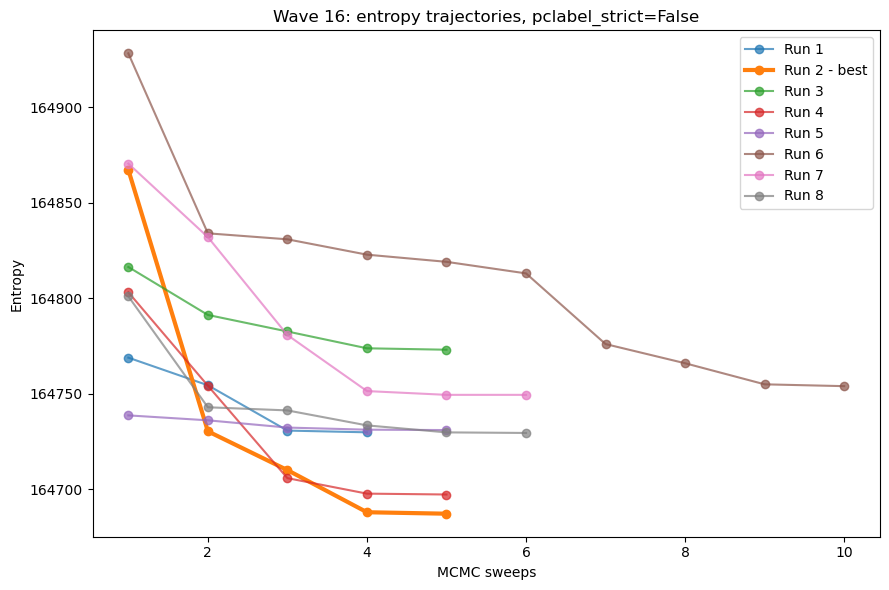

In [37]:
plot_entropy_trajectories(runs=runs_16_false, best_run_info=best_run_info_16_false, wave=16, pclabel_strict=False)

### Overlap between rounds in one wave:

In [44]:
overlap_results_16_false = Overlaps_between_runs(sbm_both=sbm_16_both, runs=runs_16_both, wave_label=16, scenario_label=False, level="group_l0", n_perm=10000)

overlap_results_16_false

,wave,pclabel_strict,level,run_a,run_b,state_dump_index_a,state_dump_index_b,overlap_observed,null_mean,null_std,p_value,final_entropy_a,final_entropy_b,min_entropy_a,min_entropy_b
0,16,False,group_l0,1,2,0,1,0.82650,0.152976,0.003148,0.0001,164729.743455,164687.135179,164729.743455,164687.135179
1,16,False,group_l0,1,3,0,2,0.77000,0.148613,0.003275,0.0001,164729.743455,164772.980274,164729.743455,164772.980274
2,16,False,group_l0,1,4,0,3,0.83025,0.153391,0.003258,0.0001,164729.743455,164697.187870,164729.743455,164697.187870
3,16,False,group_l0,1,5,0,4,0.93675,0.149716,0.003104,0.0001,164729.743455,164730.920925,164729.743455,164730.920925
4,16,False,group_l0,1,6,0,5,0.76650,0.150360,0.003297,0.0001,164729.743455,164753.909802,164729.743455,164753.909802
5,16,False,group_l0,1,7,0,6,0.87900,0.154398,0.003204,0.0001,164729.743455,164749.352345,164729.743455,164749.352345
6,16,False,group_l0,1,8,0,7,0.90075,0.152985,0.003127,0.0001,164729.743455,164729.408598,164729.743455,164729.408598
7,16,False,group_l0,2,3,1,2,0.80425,0.158058,0.004165,0.0001,164687.135179,164772.980274,164687.135179,164772.980274
8,16,False,group_l0,2,4,1,3,0.94700,0.162063,0.004068,0.0001,164687.135179,164697.187870,164687.135179,164697.187870
9,16,False,group_l0,2,5,1,4,0.79275,0.152795,0.003142,0.0001,164687.135179,164730.920925,164687.135179,164730.920925


In [45]:
overlap_results_16_false.describe()

,wave,run_a,run_b,state_dump_index_a,state_dump_index_b,overlap_observed,null_mean,null_std,p_value,final_entropy_a,final_entropy_b,min_entropy_a,min_entropy_b
count,28.0,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,2.800000e+01,28.000000,28.000000,28.000000,28.000000
mean,16.0,3.000000,6.000000,2.000000,5.000000,0.825179,0.155644,0.003545,9.999000e-05,164726.235816,164736.423797,164726.235816,164736.423797
std,0.0,1.763834,1.763834,1.763834,1.763834,0.071496,0.004399,0.000450,1.380122e-20,30.847031,21.703215,30.847031,21.703215
min,16.0,1.000000,2.000000,0.000000,1.000000,0.712750,0.148051,0.003070,9.999000e-05,164687.135179,164687.135179,164687.135179,164687.135179
25%,16.0,1.750000,5.000000,0.750000,4.000000,0.781937,0.152931,0.003151,9.999000e-05,164697.187870,164729.408598,164697.187870,164729.408598
50%,16.0,3.000000,6.000000,2.000000,5.000000,0.806375,0.154434,0.003319,9.999000e-05,164729.743455,164730.920925,164729.743455,164730.920925
75%,16.0,4.000000,7.250000,3.000000,6.250000,0.884437,0.159390,0.004060,9.999000e-05,164750.491710,164750.491710,164750.491710,164750.491710
max,16.0,7.000000,8.000000,6.000000,7.000000,0.960500,0.162063,0.004326,9.999000e-05,164772.980274,164772.980274,164772.980274,164772.980274


## Wave 20

In [49]:
sbm_20_both, runs_20_both, summary_20_both = run_wave_sbm_two_scenarios(wave=20, graphs=graphs, n_runs_per_scenario=8, 
                                                                                    scenarios=(False, True), block_sweeps=100, 
                                                                                    delta_threshold=1.0, max_blocks=100, 
                                                                                    beta=np.inf, verbose=True)


Starting wave 20, pclabel_strict=False, scenario run 1/8
Running MCMC. Params:  {'beta': inf, 'niter': 10, 'psplit': 1.0, 'pmerge': 1.0, 'pmergesplit': 1.0, 'd': 1.0}
State:  <NestedBlockState object, with base <LayeredBlockState object with 2 blocks, 5 edge covariates, degree-corrected, for graph <Graph object, undirected, with 4020 vertices and 75015 edges, 5 internal vertex properties, 6 internal edge properties, at 0x4b4f6a5d0>, at 0x4b4f25bd0>, and 13 levels of sizes [(4020, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2)] at 0x4b4f1cdd0>
Initial entropy:  190853.8468993333
Entropy after MCMC:  170212.56585139898
MCMC complete. Total time:  178.96166896820068

state_dump index 0, block 1: initial entropy = 190853.847, new entropy = 170212.566, delta = 20641.281
Running MCMC. Params:  {'beta': inf, 'niter': 10, 'psplit': 1.0, 'pmerge': 1.0, 'pmergesplit': 1.0, 'd': 1.0}
State:  <NestedBlockState object, with base <LayeredBlockStat

In [50]:
save_sbm_results(sbm_both=sbm_20_both, runs_both=runs_20_both, summary_both=summary_20_both, wave=20, save_dir="/Users/zhina/Downloads/Polarization/Saved_SBM_2")

Saved wave 20 results to: /Users/zhina/Downloads/Polarization/Saved_SBM_2


In [51]:
pd.DataFrame(summary_20_both)

,wave,scenario_run_id,state_dump_index,pclabel_strict,final_entropy,min_entropy,n_blocks,total_sweeps
0,20,1,0,False,170194.795119,170194.795119,3,300
1,20,2,1,False,170197.236313,170197.236313,6,600
2,20,3,2,False,170139.186799,170139.186799,11,1100
3,20,4,3,False,170096.549941,170096.549941,8,800
4,20,5,4,False,170128.673107,170128.673107,7,700
5,20,6,5,False,170211.711620,170211.711620,4,400
6,20,7,6,False,170207.077628,170207.077628,3,300
7,20,8,7,False,170113.898469,170113.898469,8,800
8,20,1,8,True,171137.546807,171137.546807,6,600
9,20,2,9,True,171122.653339,171122.653339,6,600


In [52]:
best_20_false = get_best_scenario_results(sbm_both=sbm_20_both, runs_both=runs_20_both, summary_both=summary_20_both, pclabel_strict=False)

runs_20_false = best_20_false["runs_scenario"]
vertex_info_20_false = best_20_false["vertex_info"]
question_blocks_20_false = best_20_false["question_blocks"]
best_run_info_20_false = best_20_false["best_run_info"]
best_state_index_20_false = best_20_false["best_state_index"]

question_blocks_20_false

Best pclabel_strict=False state_dump index: 3
Best pclabel_strict=False entropy: 170096.54994136107


,name,vertex_number,kind,kind_strict,orientation,group_l0,group_l1,group_l2,group_l3,group_l4,group_l5,group_l6,group_l7,group_l8,group_l9,group_l10,group_l11,group_l12
4018,al4W20,4018,1,19,0,15,2,2,1,1,1,1,1,1,1,1,1,1
4015,al1W20,4015,1,16,0,1157,2,2,1,1,1,1,1,1,1,1,1,1
4019,al5W20,4019,1,20,0,1157,2,2,1,1,1,1,1,1,1,1,1,1
4000,leftRightW20,4000,1,1,0,1501,2,2,1,1,1,1,1,1,1,1,1,1
4017,al3W20,4017,1,18,0,2305,2,2,1,1,1,1,1,1,1,1,1,1
4008,immigEconW20,4008,1,9,0,78,3,2,1,1,1,1,1,1,1,1,1,1
4006,enviroGrowthW20,4006,1,7,0,103,3,2,1,1,1,1,1,1,1,1,1,1
4001,turnoutUKGeneralW20,4001,1,2,0,1126,3,2,1,1,1,1,1,1,1,1,1,1
4002,polAttentionW20,4002,1,3,0,1720,3,2,1,1,1,1,1,1,1,1,1,1
4004,europeannessW20,4004,1,5,0,2257,3,2,1,1,1,1,1,1,1,1,1,1


In [53]:
best_20_true = get_best_scenario_results(sbm_both=sbm_20_both, runs_both=runs_20_both, summary_both=summary_20_both, pclabel_strict=True)

vertex_info_20_true = best_20_true["vertex_info"]
question_blocks_20_true = best_20_true["question_blocks"]
runs_20_true = best_20_true["runs_scenario"]
best_run_info_20_true = best_20_true["best_run_info"]
best_state_index_20_true = best_20_true["best_state_index"]

question_blocks_20_true

Best pclabel_strict=True state_dump index: 13
Best pclabel_strict=True entropy: 170975.7839790999


,name,vertex_number,kind,kind_strict,orientation,group_l0,group_l1,group_l2,group_l3,group_l4,group_l5,group_l6,group_l7,group_l8,group_l9,group_l10,group_l11,group_l12
4000,leftRightW20,4000,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1
4001,turnoutUKGeneralW20,4001,1,2,0,2,2,2,2,2,2,2,2,2,2,2,2,1
4002,polAttentionW20,4002,1,3,0,3,3,3,3,3,3,3,3,3,3,3,3,1
4003,britishnessW20,4003,1,4,0,4,4,4,4,4,4,4,4,4,4,4,4,1
4004,europeannessW20,4004,1,5,0,5,5,5,5,5,5,5,5,5,5,5,5,1
4005,trustMPsW20,4005,1,6,0,6,6,6,6,6,6,6,6,6,6,6,6,1
4006,enviroGrowthW20,4006,1,7,0,7,7,7,7,7,7,7,7,7,7,7,7,1
4007,redistSelfW20,4007,1,8,0,8,8,8,8,8,8,8,8,8,8,8,8,1
4008,immigEconW20,4008,1,9,0,9,9,9,9,9,9,9,9,9,9,9,9,1
4009,EUIntegrationSelfW20,4009,1,10,0,10,10,10,10,10,10,10,10,10,10,10,10,1


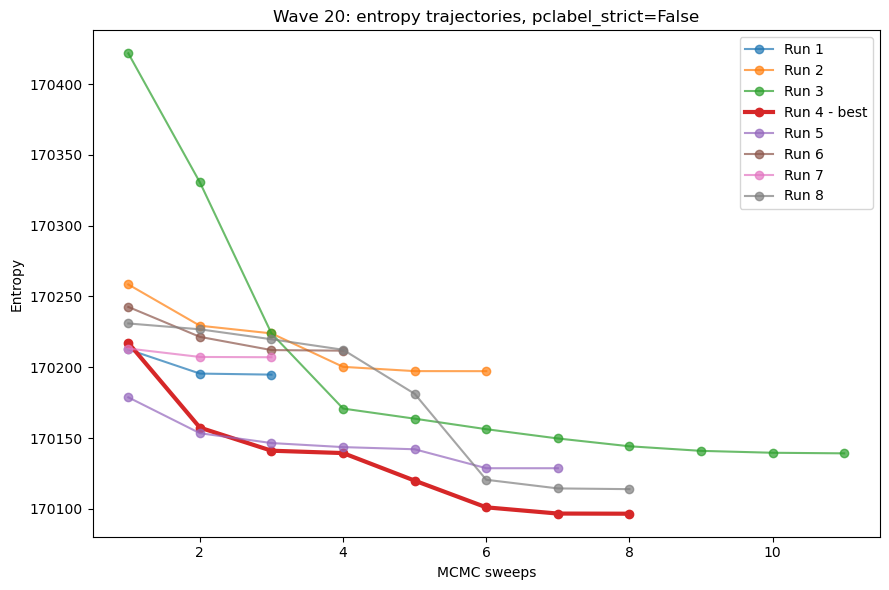

In [54]:
plot_entropy_trajectories(runs=runs_20_false, best_run_info=best_run_info_20_false, wave=20, pclabel_strict=False)

### Overlap between rounds in one wave:

In [57]:
overlap_results_20_false = Overlaps_between_runs(sbm_both=sbm_20_both, runs=runs_20_both, wave_label=20, scenario_label=False, level="group_l0", n_perm=10000)

overlap_results_20_false

,wave,pclabel_strict,level,run_a,run_b,state_dump_index_a,state_dump_index_b,overlap_observed,null_mean,null_std,p_value,final_entropy_a,final_entropy_b,min_entropy_a,min_entropy_b
0,20,False,group_l0,1,2,0,1,0.79500,0.166461,0.004186,0.0001,170194.795119,170197.236313,170194.795119,170197.236313
1,20,False,group_l0,1,3,0,2,0.61750,0.149472,0.003234,0.0001,170194.795119,170139.186799,170194.795119,170139.186799
2,20,False,group_l0,1,4,0,3,0.93850,0.169546,0.004391,0.0001,170194.795119,170096.549941,170194.795119,170096.549941
3,20,False,group_l0,1,5,0,4,0.93775,0.164925,0.004282,0.0001,170194.795119,170128.673107,170194.795119,170128.673107
4,20,False,group_l0,1,6,0,5,0.95950,0.167008,0.004302,0.0001,170194.795119,170211.711620,170194.795119,170211.711620
5,20,False,group_l0,1,7,0,6,0.96000,0.169614,0.004343,0.0001,170194.795119,170207.077628,170194.795119,170207.077628
6,20,False,group_l0,1,8,0,7,0.72925,0.153141,0.003163,0.0001,170194.795119,170113.898469,170194.795119,170113.898469
7,20,False,group_l0,2,3,1,2,0.72400,0.149932,0.003268,0.0001,170197.236313,170139.186799,170197.236313,170139.186799
8,20,False,group_l0,2,4,1,3,0.80725,0.166891,0.004251,0.0001,170197.236313,170096.549941,170197.236313,170096.549941
9,20,False,group_l0,2,5,1,4,0.77750,0.162731,0.004148,0.0001,170197.236313,170128.673107,170197.236313,170128.673107


In [58]:
overlap_results_20_false.describe()

,wave,run_a,run_b,state_dump_index_a,state_dump_index_b,overlap_observed,null_mean,null_std,p_value,final_entropy_a,final_entropy_b,min_entropy_a,min_entropy_b
count,28.0,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,2.800000e+01,28.000000,28.000000,28.000000,28.000000
mean,20.0,3.000000,6.000000,2.000000,5.000000,0.794616,0.158991,0.003776,9.999000e-05,170165.915631,170156.366618,170165.915631,170156.366618
std,0.0,1.763834,1.763834,1.763834,1.763834,0.122248,0.008561,0.000567,1.380122e-20,40.639565,46.916886,40.639565,46.916886
min,20.0,1.000000,2.000000,0.000000,1.000000,0.604500,0.144989,0.003046,9.999000e-05,170096.549941,170096.549941,170096.549941,170096.549941
25%,20.0,1.750000,5.000000,0.750000,4.000000,0.723625,0.150289,0.003202,9.999000e-05,170136.558376,170113.898469,170136.558376,170113.898469
50%,20.0,3.000000,6.000000,2.000000,5.000000,0.780250,0.162918,0.004167,9.999000e-05,170194.795119,170133.929953,170194.795119,170133.929953
75%,20.0,4.000000,7.250000,3.000000,6.250000,0.933813,0.166902,0.004299,9.999000e-05,170197.236313,170207.077628,170197.236313,170207.077628
max,20.0,7.000000,8.000000,6.000000,7.000000,0.960000,0.169984,0.004441,9.999000e-05,170211.711620,170211.711620,170211.711620,170211.711620


## Wave 25:

In [78]:
sbm_25_both, runs_25_both, summary_25_both = run_wave_sbm_two_scenarios(wave=25, graphs=graphs, n_runs_per_scenario=8, 
                                                                                    scenarios=(False, True), block_sweeps=100, 
                                                                                    delta_threshold=1.0, max_blocks=100, 
                                                                                    beta=np.inf, verbose=True)


Starting wave 25, pclabel_strict=False, scenario run 1/8
Running MCMC. Params:  {'beta': inf, 'niter': 10, 'psplit': 1.0, 'pmerge': 1.0, 'pmergesplit': 1.0, 'd': 1.0}
State:  <NestedBlockState object, with base <LayeredBlockState object with 2 blocks, 5 edge covariates, degree-corrected, for graph <Graph object, undirected, with 4020 vertices and 75179 edges, 5 internal vertex properties, 6 internal edge properties, at 0x5efedc4b0>, at 0x5efe8f250>, and 13 levels of sizes [(4020, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2)] at 0x4b4f67750>
Initial entropy:  192199.41825285484
Entropy after MCMC:  171049.6186481117
MCMC complete. Total time:  79.52646088600159

state_dump index 0, block 1: initial entropy = 192199.418, new entropy = 171049.619, delta = 21149.800
Running MCMC. Params:  {'beta': inf, 'niter': 10, 'psplit': 1.0, 'pmerge': 1.0, 'pmergesplit': 1.0, 'd': 1.0}
State:  <NestedBlockState object, with base <LayeredBlockState

In [79]:
save_sbm_results(sbm_both=sbm_25_both, runs_both=runs_25_both, summary_both=summary_25_both, wave=25, save_dir="/Users/zhina/Downloads/Polarization/Saved_SBM_2")

Saved wave 25 results to: /Users/zhina/Downloads/Polarization/Saved_SBM_2


In [80]:
pd.DataFrame(summary_25_both)

,wave,scenario_run_id,state_dump_index,pclabel_strict,final_entropy,min_entropy,n_blocks,total_sweeps
0,25,1,0,False,170946.954887,170946.954887,10,1000
1,25,2,1,False,171037.715460,171037.715460,4,400
2,25,3,2,False,171044.357692,171044.357692,8,800
3,25,4,3,False,170960.202478,170960.202478,7,700
4,25,5,4,False,171061.234945,171061.234945,4,400
5,25,6,5,False,170949.224056,170949.224056,7,700
6,25,7,6,False,171044.106017,171044.106017,5,500
7,25,8,7,False,170977.591007,170977.591007,3,300
8,25,1,8,True,171788.250717,171788.250717,5,500
9,25,2,9,True,171733.811822,171733.811822,7,700


In [81]:
best_25_false = get_best_scenario_results(sbm_both=sbm_25_both, runs_both=runs_25_both, summary_both=summary_25_both, pclabel_strict=False)

runs_25_false = best_25_false["runs_scenario"]
vertex_info_25_false = best_25_false["vertex_info"]
question_blocks_25_false = best_25_false["question_blocks"]
best_run_info_25_false = best_25_false["best_run_info"]
best_state_index_25_false = best_25_false["best_state_index"]

question_blocks_25_false

Best pclabel_strict=False state_dump index: 0
Best pclabel_strict=False entropy: 170946.95488662765


,name,vertex_number,kind,kind_strict,orientation,group_l0,group_l1,group_l2,group_l3,group_l4,group_l5,group_l6,group_l7,group_l8,group_l9,group_l10,group_l11,group_l12
4006,enviroGrowthW25,4006,1,7,0,146,4,1,1,1,1,1,1,1,1,1,1,1
4001,turnoutUKGeneralW25,4001,1,2,0,888,4,1,1,1,1,1,1,1,1,1,1,1
4002,polAttentionW25,4002,1,3,0,1560,4,1,1,1,1,1,1,1,1,1,1,1
4008,immigEconW25,4008,1,9,0,2284,4,1,1,1,1,1,1,1,1,1,1,1
4004,europeannessW25,4004,1,5,0,2630,4,1,1,1,1,1,1,1,1,1,1,1
4003,britishnessW25,4003,1,4,0,2659,4,1,1,1,1,1,1,1,1,1,1,1
4010,lr1W25W26,4010,1,11,0,3,5,1,1,1,1,1,1,1,1,1,1,1
4013,lr4W25W26,4013,1,14,0,7,5,1,1,1,1,1,1,1,1,1,1,1
4011,lr2W25W26,4011,1,12,0,21,5,1,1,1,1,1,1,1,1,1,1,1
4012,lr3W25W26,4012,1,13,0,1175,5,1,1,1,1,1,1,1,1,1,1,1


In [82]:
best_25_true = get_best_scenario_results(sbm_both=sbm_25_both, runs_both=runs_25_both, summary_both=summary_25_both, pclabel_strict=True)

vertex_info_25_true = best_25_true["vertex_info"]
question_blocks_25_true = best_25_true["question_blocks"]
runs_25_true = best_25_true["runs_scenario"]
best_run_info_25_true = best_25_true["best_run_info"]
best_state_index_25_true = best_25_true["best_state_index"]

question_blocks_25_true

Best pclabel_strict=True state_dump index: 12
Best pclabel_strict=True entropy: 171629.84244901963


,name,vertex_number,kind,kind_strict,orientation,group_l0,group_l1,group_l2,group_l3,group_l4,group_l5,group_l6,group_l7,group_l8,group_l9,group_l10,group_l11,group_l12
4000,leftRightW25,4000,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,0
4001,turnoutUKGeneralW25,4001,1,2,0,2,2,2,2,2,2,2,2,2,2,2,2,0
4002,polAttentionW25,4002,1,3,0,3,3,3,3,3,3,3,3,3,3,3,3,0
4003,britishnessW25,4003,1,4,0,4,4,4,4,4,4,4,4,4,4,4,4,0
4004,europeannessW25,4004,1,5,0,5,5,5,5,5,5,5,5,5,5,5,5,0
4005,trustMPsW25,4005,1,6,0,6,6,6,6,6,6,6,6,6,6,6,6,0
4006,enviroGrowthW25,4006,1,7,0,7,7,7,7,7,7,7,7,7,7,7,7,0
4007,redistSelfW25,4007,1,8,0,8,8,8,8,8,8,8,8,8,8,8,8,0
4008,immigEconW25,4008,1,9,0,9,9,9,9,9,9,9,9,9,9,9,9,0
4009,EUIntegrationSelfW25,4009,1,10,0,10,10,10,10,10,10,10,10,10,10,10,10,0


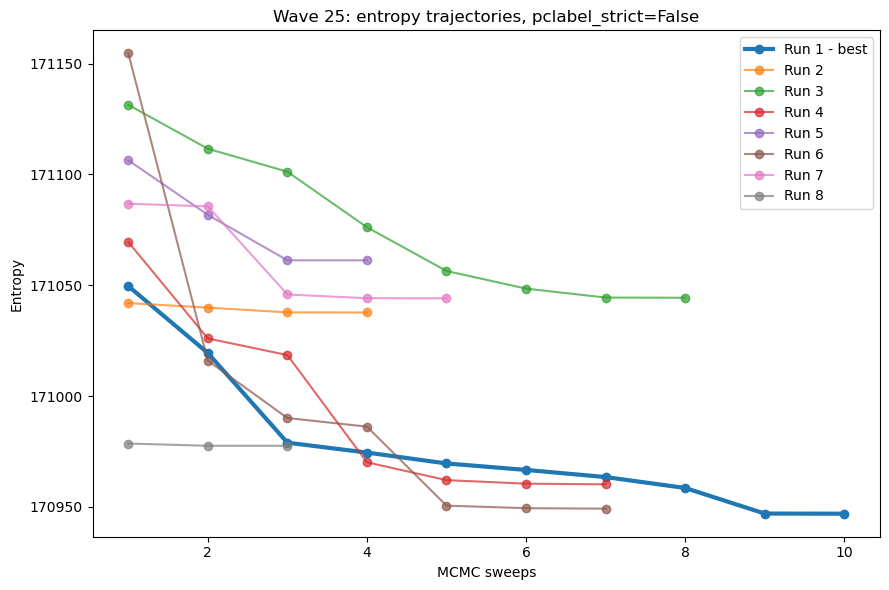

In [83]:
plot_entropy_trajectories(runs=runs_25_false, best_run_info=best_run_info_25_false, wave=25, pclabel_strict=False)

### Overlap between rounds in one wave:

In [84]:
overlap_results_25_false = Overlaps_between_runs(sbm_both=sbm_25_both, runs=runs_25_both, wave_label=25, scenario_label=False, level="group_l0", n_perm=10000)

overlap_results_25_false

,wave,pclabel_strict,level,run_a,run_b,state_dump_index_a,state_dump_index_b,overlap_observed,null_mean,null_std,p_value,final_entropy_a,final_entropy_b,min_entropy_a,min_entropy_b
0,25,False,group_l0,1,2,0,1,0.64875,0.150312,0.003586,0.0001,170946.954887,171037.715460,170946.954887,171037.715460
1,25,False,group_l0,1,3,0,2,0.63125,0.149754,0.003452,0.0001,170946.954887,171044.357692,170946.954887,171044.357692
2,25,False,group_l0,1,4,0,3,0.95225,0.135210,0.003263,0.0001,170946.954887,170960.202478,170946.954887,170960.202478
3,25,False,group_l0,1,5,0,4,0.64500,0.149958,0.003522,0.0001,170946.954887,171061.234945,170946.954887,171061.234945
4,25,False,group_l0,1,6,0,5,0.65450,0.145140,0.003410,0.0001,170946.954887,170949.224056,170946.954887,170949.224056
5,25,False,group_l0,1,7,0,6,0.64700,0.149982,0.003497,0.0001,170946.954887,171044.106017,170946.954887,171044.106017
6,25,False,group_l0,1,8,0,7,0.65950,0.143477,0.003041,0.0001,170946.954887,170977.591007,170946.954887,170977.591007
7,25,False,group_l0,2,3,1,2,0.95850,0.178015,0.003927,0.0001,171037.715460,171044.357692,171037.715460,171044.357692
8,25,False,group_l0,2,4,1,3,0.66400,0.147633,0.003474,0.0001,171037.715460,170960.202478,171037.715460,170960.202478
9,25,False,group_l0,2,5,1,4,0.98875,0.178255,0.004093,0.0001,171037.715460,171061.234945,171037.715460,171061.234945


In [85]:
overlap_results_25_false.describe()

,wave,run_a,run_b,state_dump_index_a,state_dump_index_b,overlap_observed,null_mean,null_std,p_value,final_entropy_a,final_entropy_b,min_entropy_a,min_entropy_b
count,28.0,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,2.800000e+01,28.000000,28.000000,28.000000,28.000000
mean,25.0,3.000000,6.000000,2.000000,5.000000,0.782509,0.158942,0.003539,9.999000e-05,171001.565511,171003.781125,171001.565511,171003.781125
std,0.0,1.763834,1.763834,1.763834,1.763834,0.134387,0.013557,0.000294,1.380122e-20,48.184401,44.215768,48.184401,44.215768
min,25.0,1.000000,2.000000,0.000000,1.000000,0.631250,0.135210,0.002974,9.999000e-05,170946.954887,170949.224056,170946.954887,170949.224056
25%,25.0,1.750000,5.000000,0.750000,4.000000,0.660062,0.147411,0.003338,9.999000e-05,170948.656764,170960.202478,170948.656764,170960.202478
50%,25.0,3.000000,6.000000,2.000000,5.000000,0.748875,0.161193,0.003463,9.999000e-05,171037.715460,170977.591007,171037.715460,170977.591007
75%,25.0,4.000000,7.250000,3.000000,6.250000,0.903312,0.166983,0.003739,9.999000e-05,171044.357692,171044.106017,171044.357692,171044.106017
max,25.0,7.000000,8.000000,6.000000,7.000000,0.988750,0.178353,0.004093,9.999000e-05,171061.234945,171061.234945,171061.234945,171061.234945


# Simpson score:

In [86]:
result_S_16 = compare_simpson_false_true(
    wave=16,
    wave_key="W16",
    best_false=best_16_false,
    best_true=best_16_true,
    survey_data=W16_20_25_selected_columns,
    questions_by_wave=questions_by_wave,
    level="group_l1",
    non_response_values=(9999,),
    include_non_response=True)

print("S non-strict(false):", result_S_16["S_false"])
print("S strict(true):", result_S_16["S_true"])
print("odds_false:", result_S_16["odds_false"])
print("odds_true:", result_S_16["odds_true"])
print("simpson_odds_ratio:", result_S_16["simpson_odds_ratio"])
print("percent_odds_change:", result_S_16["percent_odds_change"])

S non-strict(false): 0.35376241115683427
S strict(true): 0.38855531099451035
odds_false: 0.5474184994254307
odds_true: 0.6354709068231384
simpson_odds_ratio: 0.8614375474120421
percent_odds_change: -13.856245258795784


/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/189678890.py:41: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_df = df.stack(dropna=False).reset_index()
/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/189678890.py:41: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_df = df.stack(dropna=False).reset_index()


In [87]:
result_S_20 = compare_simpson_false_true(
    wave=20,
    wave_key="W20",
    best_false=best_20_false,
    best_true=best_20_true,
    survey_data=W16_20_25_selected_columns,
    questions_by_wave=questions_by_wave,
    level="group_l1",
    non_response_values=(9999,),
    include_non_response=True)

print("S non-strict(false):", result_S_20["S_false"])
print("S strict(true):", result_S_20["S_true"])
print("odds_false:", result_S_20["odds_false"])
print("odds_true:", result_S_20["odds_true"])
print("simpson_odds_ratio:", result_S_20["simpson_odds_ratio"])
print("percent_odds_change:", result_S_20["percent_odds_change"])

S non-strict(false): 0.3111911106250227
S strict(true): 0.3610668556975481
odds_false: 0.45178149618161345
odds_true: 0.5651089772338211
simpson_odds_ratio: 0.7994590678652111
percent_odds_change: -20.054093213478886


/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/189678890.py:41: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_df = df.stack(dropna=False).reset_index()
/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/189678890.py:41: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_df = df.stack(dropna=False).reset_index()


In [88]:
result_S_25 = compare_simpson_false_true(
    wave=25,
    wave_key="W25",
    best_false=best_25_false,
    best_true=best_25_true,
    survey_data=W16_20_25_selected_columns,
    questions_by_wave=questions_by_wave,
    level="group_l1",
    non_response_values=(9999,),
    include_non_response=True)

print("S non-strict(false):", result_S_25["S_false"])
print("S strict(true):", result_S_25["S_true"])
print("odds_false:", result_S_25["odds_false"])
print("odds_true:", result_S_25["odds_true"])
print("simpson_odds_ratio:", result_S_25["simpson_odds_ratio"])
print("percent_odds_change:", result_S_25["percent_odds_change"])

S non-strict(false): 0.3022968970359314
S strict(true): 0.36159199696984323
odds_false: 0.43327440533326617
odds_true: 0.5663964036377572
simpson_odds_ratio: 0.7649667309864662
percent_odds_change: -23.503326901353383


/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/189678890.py:41: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_df = df.stack(dropna=False).reset_index()
/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/189678890.py:41: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_df = df.stack(dropna=False).reset_index()


In [97]:
simpson_or_results = Simpson_results_table( result_S_16, result_S_20, result_S_25)
simpson_or_results

,wave,level,S_false,S_true,odds_false,odds_true,simpson_odds_ratio,percent_odds_change,percent_lower_odds
0,16,group_l1,0.353762,0.388555,0.547418,0.635471,0.861438,-13.856245,13.856245
1,20,group_l1,0.311191,0.361067,0.451781,0.565109,0.799459,-20.054093,20.054093
2,25,group_l1,0.302297,0.361592,0.433274,0.566396,0.764967,-23.503327,23.503327


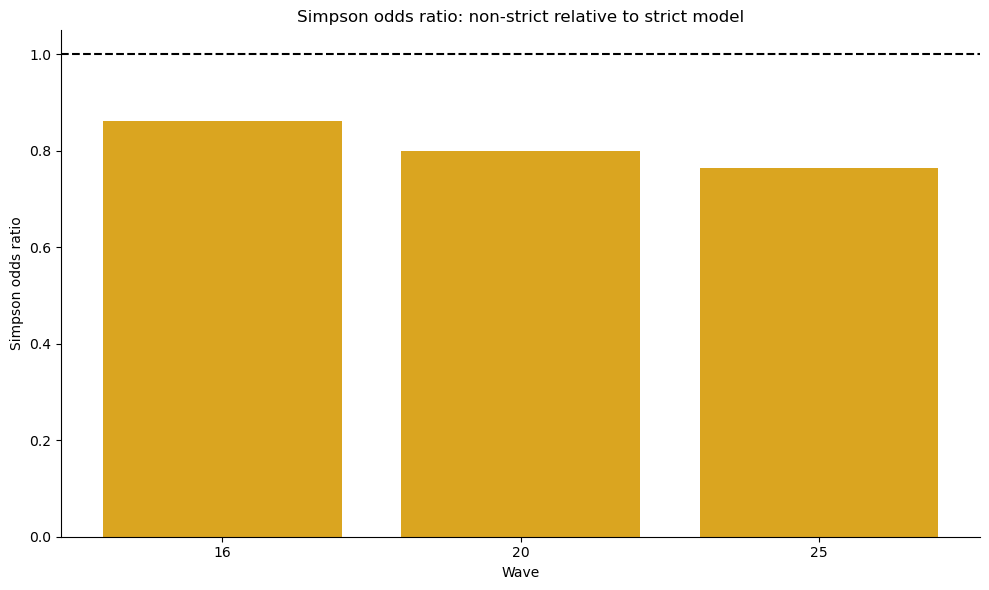

In [98]:
plot_simpson_odds_ratio(simpson_or_results)

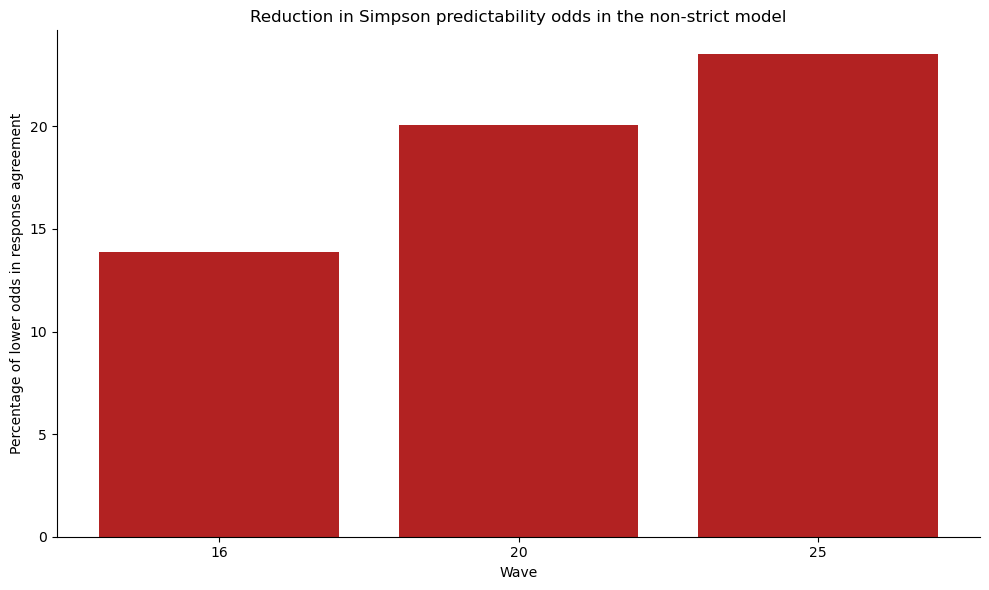

In [99]:
plot_simpson_percent_lower_odds(simpson_or_results)

# Shannon score:

In [100]:
result_H_16 = compare_shannon_false_true(
    wave=16,
    wave_key="W16",
    best_false=best_16_false,
    best_true=best_16_true,
    survey_data=W16_20_25_selected_columns,
    questions_by_wave=questions_by_wave,
    level="group_l1",
    non_response_values=(9999,),
    include_non_response=True)

print("H non-strict(false):", result_H_16["H_false"])
print("H strict(true):", result_H_16["H_true"])
print("Entropy ratio:", result_H_16["entropy_ratio"])
print("Percent uncertainty relative to strict/null:", result_H_16["percent_uncertainty_relative_to_true"])
print("Percent uncertainty change:",result_H_16["percent_uncertainty_change"])

H non-strict(false): 1.3088316721735966
H strict(true): 1.2265770434434469
Entropy ratio: 1.067060303443501
Percent uncertainty relative to strict/null: 106.70603034435008
Percent uncertainty change: 6.706030344350089


/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/3342970245.py:34: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_df = df.stack(dropna=False).reset_index()
/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/3342970245.py:34: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_df = df.stack(dropna=False).reset_index()


In [101]:
result_H_20 = compare_shannon_false_true(
    wave=20,
    wave_key="W20",
    best_false=best_20_false,
    best_true=best_20_true,
    survey_data=W16_20_25_selected_columns,
    questions_by_wave=questions_by_wave,
    level="group_l1",
    non_response_values=(9999,),
    include_non_response=True)

print("H non-strict(false):", result_H_20["H_false"])
print("H strict(true):", result_H_20["H_true"])
print("Entropy ratio:", result_H_20["entropy_ratio"])
print("Percent uncertainty relative to strict/null:", result_H_20["percent_uncertainty_relative_to_true"])
print("Percent uncertainty change:",result_H_20["percent_uncertainty_change"])

H non-strict(false): 1.3978204570894233
H strict(true): 1.2825156473132766
Entropy ratio: 1.0899051875255457
Percent uncertainty relative to strict/null: 108.99051875255456
Percent uncertainty change: 8.990518752554566


/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/3342970245.py:34: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_df = df.stack(dropna=False).reset_index()
/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/3342970245.py:34: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_df = df.stack(dropna=False).reset_index()


In [102]:
result_H_25 = compare_shannon_false_true(
    wave=25,
    wave_key="W25",
    best_false=best_25_false,
    best_true=best_25_true,
    survey_data=W16_20_25_selected_columns,
    questions_by_wave=questions_by_wave,
    level="group_l1",
    non_response_values=(9999,),
    include_non_response=True)

print("H non-strict(false):", result_H_25["H_false"])
print("H strict(true):", result_H_25["H_true"])
print("Entropy ratio:", result_H_25["entropy_ratio"])
print("Percent uncertainty relative to strict/null:", result_H_25["percent_uncertainty_relative_to_true"])
print("Percent uncertainty change:",result_H_25["percent_uncertainty_change"])

H non-strict(false): 1.4185152508927614
H strict(true): 1.2862746243750793
Entropy ratio: 1.1028090145072478
Percent uncertainty relative to strict/null: 110.28090145072478
Percent uncertainty change: 10.280901450724777


/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/3342970245.py:34: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_df = df.stack(dropna=False).reset_index()
/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/3342970245.py:34: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_df = df.stack(dropna=False).reset_index()


In [104]:
shannon_results = make_shannon_results_table(result_H_16, result_H_20, result_H_25)

shannon_results

,wave,level,H_false,H_true,comparison_ratio,percent_more_uncertainty
0,16,group_l1,1.308832,1.226577,1.067060,6.706030
1,20,group_l1,1.397820,1.282516,1.089905,8.990519
2,25,group_l1,1.418515,1.286275,1.102809,10.280901


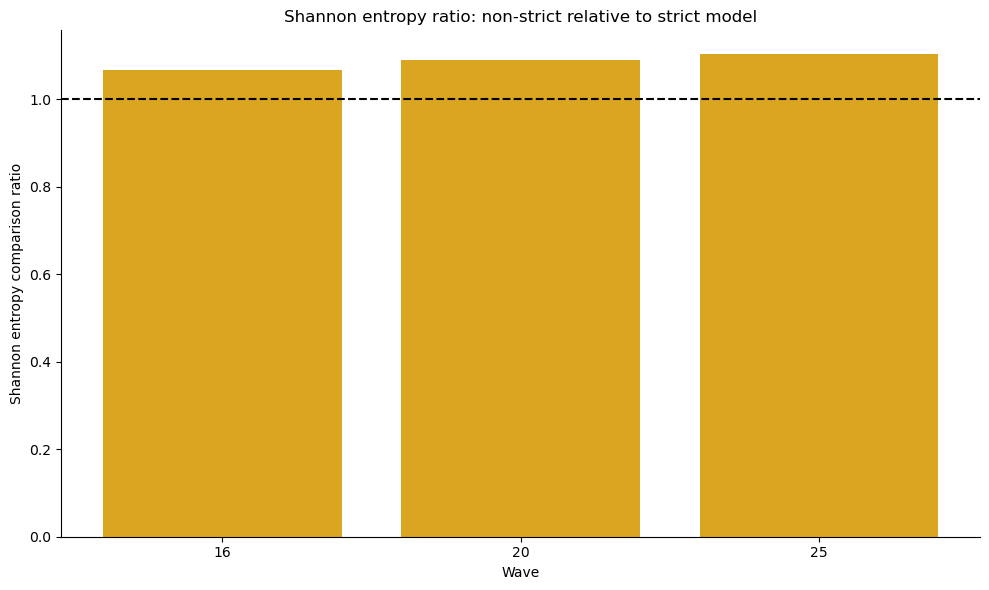

In [106]:
plot_shannon_comparison_ratio(shannon_results)

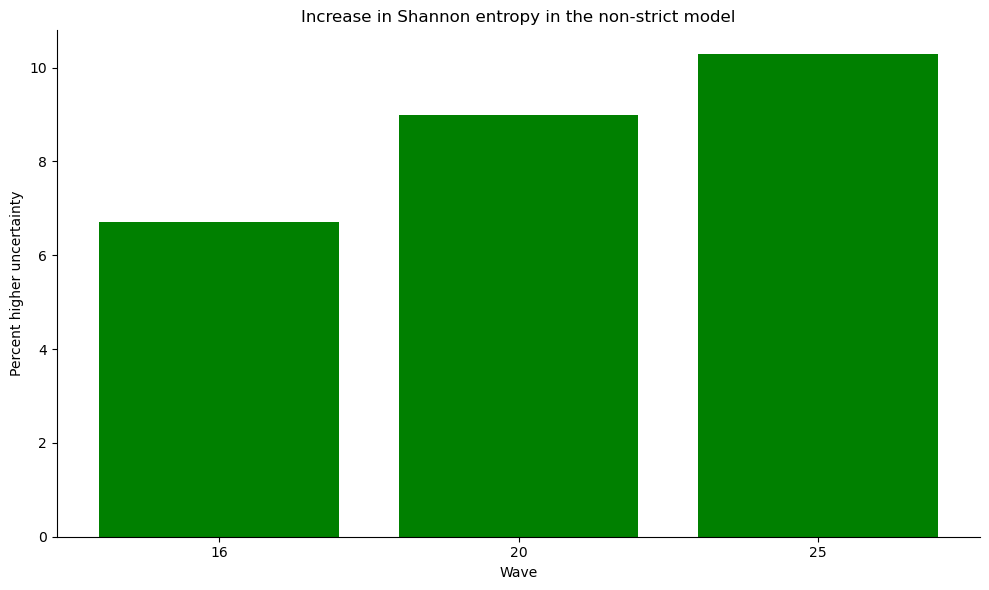

In [108]:
plot_shannon_percent_more_uncertainty(shannon_results)

# Overlaps across waves

`plot_overlap_boxplot` Plot boxplots of observed pairwise overlaps by wave, with the mean null overlap shown as a cross.

In [ ]:
def plot_overlap_boxplot(overlap_all_false, wave_order=("16", "20", "25"), figsize=(10, 6), null_marker_color="green"):

    # Make sure wave is string for matching
    df = overlap_all_false.copy()
    df["wave"] = df["wave"].astype(str)

    data_to_plot = [
        df.loc[df["wave"] == wave, "overlap_observed"]
        for wave in wave_order]

    plt.figure(figsize=figsize)

    plt.boxplot(
        data_to_plot,
        labels=[f"Wave {wave}" for wave in wave_order])

    # Add wave-specific null means
    for i, wave in enumerate(wave_order, start=1):
        null_mean_wave = df.loc[
            df["wave"] == wave,
            "null_mean"].mean()

        plt.scatter(
            i,
            null_mean_wave,
            marker="x",
            s=80,
            color=null_marker_color,
            label="Mean null overlap" if i == 1 else None)

    plt.xlabel("Wave")
    plt.ylabel("Partition overlap")
    plt.title("Observed run overlap compared with null overlap")
    plt.legend()

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1922/206911388.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


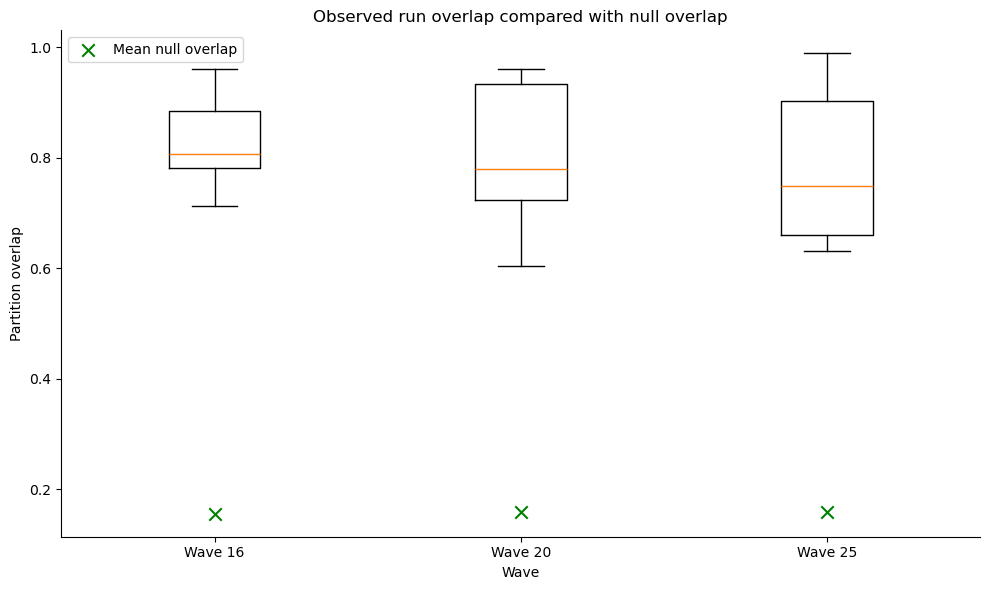

In [110]:
overlap_all_false = pd.concat([overlap_results_16_false, overlap_results_20_false, overlap_results_25_false],ignore_index=True)

plot_overlap_boxplot(overlap_all_false)

## Heatmap of pairwise overlaps between runs

`Overlap_heatmap` Plots the heatmap of overlap between runs.

In [ ]:
def make_overlap_matrix(overlap_results):
    runs = sorted(
        set(overlap_results["run_a"]).union(set(overlap_results["run_b"])))

    overlap_matrix = pd.DataFrame(
        np.eye(len(runs)),
        index=runs,
        columns=runs)

    for _, row in overlap_results.iterrows():
        run_a = row["run_a"]
        run_b = row["run_b"]
        overlap = row["overlap_observed"]

        overlap_matrix.loc[run_a, run_b] = overlap
        overlap_matrix.loc[run_b, run_a] = overlap

    return overlap_matrix


def Overlap_heatmap(results_list, wave_labels):
    matrices = [
        make_overlap_matrix(results)
        for results in results_list]

    # Shared color scale across all heatmaps
    global_min = min(matrix.values.min() for matrix in matrices)
    global_max = max(matrix.values.max() for matrix in matrices)

    fig, axes = plt.subplots(
        1,
        len(matrices),
        figsize=(6 * len(matrices), 5),
        constrained_layout=True)

    if len(matrices) == 1:
        axes = [axes]

    for ax, matrix, wave_label in zip(axes, matrices, wave_labels):
        im = ax.imshow(
        matrix,
        aspect="auto",
        vmin=global_min,
        vmax=global_max,
        cmap="viridis_r"
        )

        runs = matrix.index.tolist()

        ax.set_xticks(np.arange(len(runs)))
        ax.set_xticklabels(runs)

        ax.set_yticks(np.arange(len(runs)))
        ax.set_yticklabels(runs)

        ax.set_xlabel("Run")
        ax.set_ylabel("Run")
        ax.set_title(f"Wave {wave_label}")

        for i in range(len(runs)):
            for j in range(len(runs)):
                ax.text(
                    j,
                    i,
                    f"{matrix.iloc[i, j]:.2f}",
                    ha="center",
                    va="center"
                )

    fig.colorbar(
        im,
        ax=axes,
        label="Observed partition overlap",
        shrink=0.8)

    fig.suptitle("Pairwise SBM partition overlap", fontsize=14)

    plt.show()

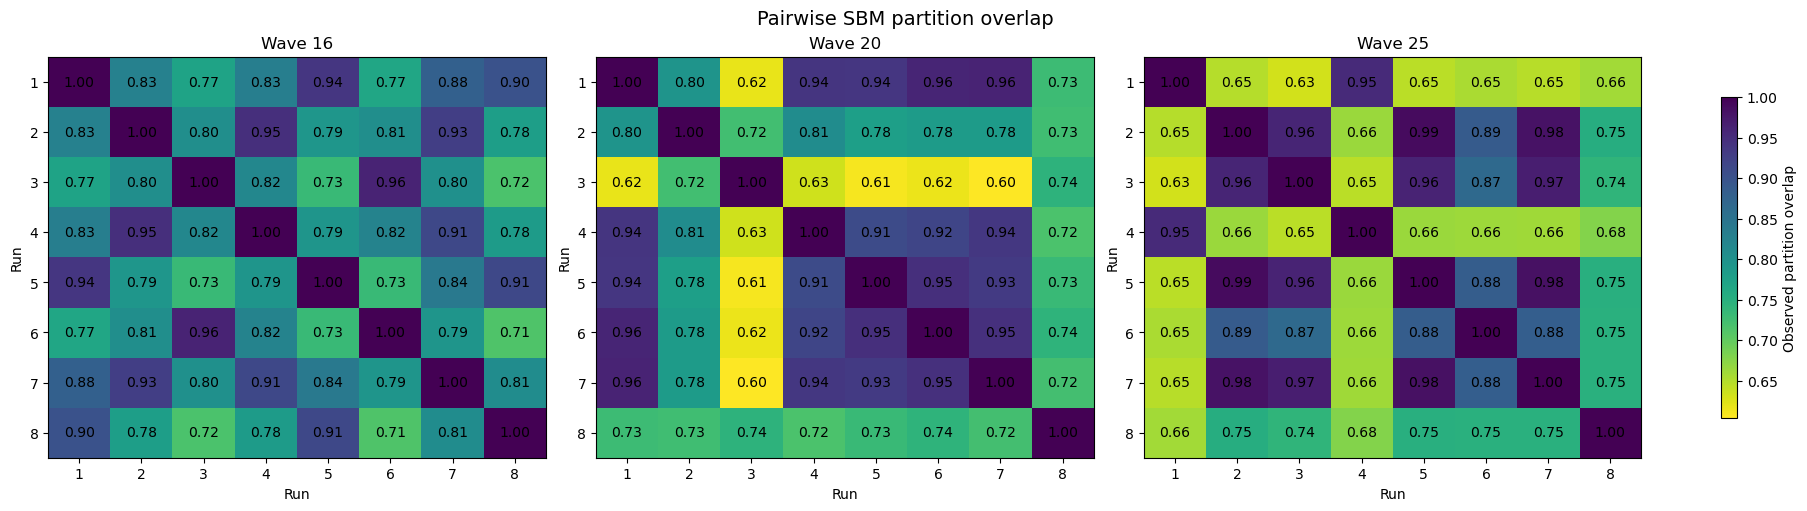

In [122]:
Overlap_heatmap(
    results_list=[
        overlap_results_16_false,
        overlap_results_20_false,
        overlap_results_25_false
    ],
    wave_labels=[16, 20, 25])

# Overlap across runs

`plot_overlap_between_waves` Compare respondent partitions across waves using already extracted best scenario results, then plot observed partition overlaps.

In [ ]:
def plot_overlap_between_waves( best_by_wave, waves=(16, 20, 25), level="group_l0", n_perm=10000, figsize=(9, 7), color="darkolivegreen", return_results=False):

    partitions = {}

    # Extract respondent partitions from already saved vertex_info
    for wave in waves:
        vertex_info = best_by_wave[wave]["vertex_info"]

        part_df = vertex_info.loc[
            vertex_info["kind"] == 0,
            ["name", level]].copy()

        part_df["name"] = part_df["name"].astype(str)
        part_df = part_df.rename(columns={level: f"group_{wave}"})

        partitions[wave] = part_df

    results = []

    # Pairwise wave comparisons
    for wave_a, wave_b in combinations(waves, 2):
        part_a = partitions[wave_a]
        part_b = partitions[wave_b]

        group_col_a = f"group_{wave_a}"
        group_col_b = f"group_{wave_b}"

        merged = part_a.merge(part_b, on="name", how="inner")

        b_a = merged[group_col_a].values
        b_b = merged[group_col_b].values

        overlap_observed = gt.partition_overlap(b_a, b_b, norm=True)

        null = np.zeros(n_perm)

        for i in range(n_perm):
            b_b_permuted = np.random.permutation(b_b)

            null[i] = gt.partition_overlap(
                b_a,
                b_b_permuted,
                norm=True)

        p_value = (1 + np.sum(null >= overlap_observed)) / (n_perm + 1)

        results.append({
            "wave_a": wave_a,
            "wave_b": wave_b,
            "pair_label": f"Wave {wave_a}–{wave_b}",
            "n_common_respondents": len(merged),
            "overlap_observed": overlap_observed,
            "null_mean": null.mean(),
            "null_std": null.std(),
            "p_value": p_value})

    overlap_between_waves = pd.DataFrame(results)

    # Plot observed overlaps
    x = np.arange(len(overlap_between_waves))

    plt.figure(figsize=figsize)

    plt.errorbar(
        x,
        overlap_between_waves["overlap_observed"],
        fmt="o-",
        markersize=10,
        linewidth=2,
        capsize=2,
        color=color)

    plt.xticks(
        x,
        overlap_between_waves["pair_label"],
        fontsize=14)

    plt.ylabel("Partition overlap", fontsize=16)
    plt.ylim(0, 1)
    plt.tick_params(axis="both", width=2, length=8)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)

    plt.tight_layout()
    plt.show()

    if return_results:
        return overlap_between_waves

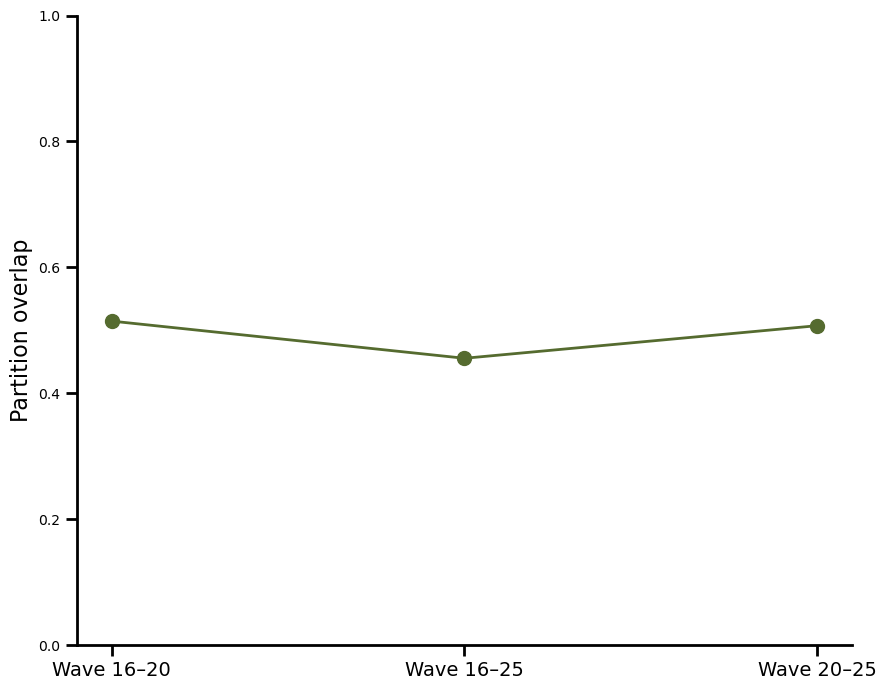

,wave_a,wave_b,pair_label,n_common_respondents,overlap_observed,null_mean,null_std,p_value
0,16,20,Wave 16–20,4000,0.51450,0.163632,0.004246,0.0001
1,16,25,Wave 16–25,4000,0.45550,0.145226,0.003587,0.0001
2,20,25,Wave 20–25,4000,0.50725,0.148824,0.003909,0.0001


In [124]:
best_false_by_wave = {
    16: best_16_false,
    20: best_20_false,
    25: best_25_false}

overlap_between_waves_false = plot_overlap_between_waves( best_by_wave=best_false_by_wave, waves=(16, 20, 25), level="group_l0", n_perm=10000, return_results=True)

overlap_between_waves_false

# Figures 

`plot_SBM_networks` Plot fitted SurveySBM object.

`plot_all_SBM_network_runs` Plot all runs stored inside the same SurveySBM object next to each other.

In [ ]:
# Custom color map
color1 = '#e31f26'
color2 = '#fcb315'
color3 = '#006eb8'

cmap = LinearSegmentedColormap.from_list(
    "custom_3color",
    [(0.0, color1),
     (0.1, color1),
     (0.45, color2),
     (0.55, color2),
     (0.9, color3),
     (1.0, color3)])

# Question labels
name_map = {
    'leftRight': 'leftRight: Left-right self-placement (0–10)',
    'turnoutUKGeneral': 'Likelihood of voting (1–5)',
    'polAttention': 'Attention to politics (0–10)',

    'britishness': 'Britishness scale (1–7)',
    'europeanness': 'Europeanness scale (1–7)',

    'trustMPs': 'Trust in Members of Parliament (1–7)',
    'enviroGrowth': 'Environment priority vs economic growth (0–10)',
    'redistSelf': 'Government efforts for income equality (0–10)',
    'immigEcon': 'Immigration good/bad for Britain’s economy (1–7)',
    'EUIntegrationSelf': 'EU integration / Brexit position (0–10)',

    'lr1': 'Government should redistribute income (1–5)',
    'lr2': 'Big business takes advantage of ordinary people (1–5)',
    'lr3': 'Working people do not get fair share of wealth (1–5)',
    'lr4': 'One law for rich and one for poor (1–5)',
    'lr5': 'Management tries to get the better of employees (1–5)',

    'al1': 'Young people lack respect for traditional British values (1–5)',
    'al2': 'Death penalty appropriate for some crimes (1–5)',
    'al3': 'Schools should teach children to obey authority (1–5)',
    'al4': 'Censorship needed to uphold moral standards (1–5)',
    'al5': 'Lawbreakers should get stiffer sentences (1–5)'
}

In [132]:
def plot_SBM_networks(sbm, ax, cmap, name_map, levels=(0, 1, 2), subsample_edges=10000, title=None, show_question_labels=True, show_respondent_labels=True):

    ax.axis('off')

    # Make sure vertex info exists
    sbm.add_vertex_info()

    # Extract graph/state
    state = sbm.state_dump[sbm.current_run]['state']
    g = state.g

    # Add edge index property
    edge_index = g.ep["edge_index"] = g.new_ep("int")
    for c, e in enumerate(g.edges()):
        edge_index[e] = c

    sbm.state_dump[sbm.current_run]['state'] = state

    # Choose hierarchy level:
    # keep levels until the first state with 2 nonempty blocks
    L = 0
    for level_state in sbm.state_dump[sbm.current_run]['state'].levels:
        L += 1
        if level_state.get_nonempty_B() == 2:
            break

    state = sbm.state_dump[sbm.current_run]['state'].copy(
        bs=sbm.state_dump[sbm.current_run]['state'].get_bs()[:L] + [np.zeros(1)])

    # Set vertex text and size
    vtext = state.g.vp["vtext"] = state.g.new_vp("string")
    vsize = state.g.vp["vsize"] = state.g.new_vp("double")

    kind_old = state.g.vp["kind"].a
    name_old = list(state.g.vp["name"])

    for v in state.g.get_vertices():
        if kind_old[v] == 1:
            vtext[v] = name_old[v]
            vsize[v] = 15.0
        else:
            vtext[v] = ''
            vsize[v] = 0.0

    # Edge colors
    ecolor = state.g.ep.weight
    ecolor = gt.prop_to_size(ecolor)

    # Draw graph
    pos, t, tpos = state.draw(
        layout='bipartite',
        edge_color=ecolor,
        vertex_size=state.g.vp.vsize,
        vertex_color='k',
        vertex_pen_width=1.5,
        vertex_fill_color='gray',
        adjust_aspect=False,
        hedge_pen_width=2.0,
        hvertex_size=10,
        hedge_color='gray',
        hvertex_color='k',
        hvertex_pen_width=1.5,
        hvertex_fill_color='gray',
        ecmap=(cmap, 0.5),
        edge_gradient=[],
        edge_pen_width=0.12,
        hshortcuts=1,
        hide=0,
        subsample_edges=subsample_edges,
        mplfig=ax,
        ink_scale=0.002)

    pos.fit_view(yflip=True)

    # Extract plotted vertex positions
    info = sbm.vertex_info.copy()

    p = np.array(list(pos.pos))[:len(sbm.vertex_info)]
    info['xpos'] = p[:, 0]
    info['ypos'] = p[:, 1]
    info = info.sort_values(by=['xpos', 'ypos'])

    rpos = info.loc[info.kind == 0].copy()
    qpos = info.loc[info.kind == 1].copy()

    # Add readable question labels
    qpos['base_name'] = qpos['name'].str.replace(r'W\d+(W\d+)?$', '', regex=True)
    qpos['full_name'] = qpos['base_name'].map(name_map).fillna(qpos['base_name'])

    # Calculate vertical spacing
    if len(rpos.ypos.unique()) > 1:
        rdiff = np.diff(np.sort(rpos.ypos.unique()))[0] / 2
    else:
        rdiff = 0.02

    if len(qpos.ypos.unique()) > 1:
        qdiff = np.diff(np.sort(qpos.ypos.unique()))[0] / 2
    else:
        qdiff = 0.02

    # Label positions
    qs = -0.52
    qpad = 0.06
    rs = -qs

    # Draw hierarchy boundary lines
    for l in levels:
        q_group_col = f'group_l{l}'
        r_group_col = f'group_l{l}'

        if q_group_col in qpos.columns:
            first = qpos.groupby(by=q_group_col).ypos.first().sort_values().values

            for y in first:
                ax.plot(
                    [qs, qs - (qpad * (1 + l))],
                    [y - qdiff, y - qdiff],
                    color='k',
                    lw=1.0 + (1.0 * l))

            ymax = qpos.ypos.max() + qdiff
            ax.plot(
                [qs, qs - (qpad * (1 + l))],
                [ymax, ymax],
                color='k',
                lw=1.0 + (1.0 * l))

        if r_group_col in rpos.columns:
            first = rpos.groupby(by=r_group_col).ypos.first().sort_values().values

            for y in first:
                ax.plot(
                    [rs, rs + 0.05],
                    [y - rdiff, y - rdiff],
                    color='k',
                    lw=1.0 + (1.0 * l))

            ymax = rpos.ypos.max() + rdiff
            ax.plot(
                [rs, rs + 0.05],
                [ymax, ymax],
                color='k',
                lw=1.0 + (1.0 * l))

    # Add question labels
    if show_question_labels:
        for q in range(len(qpos)):
            x = qs
            y = qpos.iloc[q].ypos
            label = qpos.iloc[q]['full_name']

            ax.text(
                x, y, label,
                ha='right', va='center',
                fontsize=5, zorder=5)

    # Add respondent group labels
    if show_respondent_labels:
        if 'group_l0' in rpos.columns:
            r_ypos = rpos.groupby(by='group_l0').ypos.mean().sort_values().values
        else:
            r_ypos = rpos.ypos.sort_values().values

        rval = len(r_ypos)

        for p_i in range(len(r_ypos)):
            x = -qs
            y = r_ypos[p_i]
            label = f'R{rval}'

            ax.text(
                x, y, label,
                ha='left', va='center',
                fontsize=7, zorder=5)
            rval -= 1

    # Plot limits
    xmin, xmax = -0.95, 0.6
    ax.set_xlim((xmin, xmax))
    ax.set_ylim((-0.56, 0.52))

    if title is not None:
        ax.set_title(title, fontsize=10)

    return ax

In [133]:
def plot_all_SBM_network_runs( sbm_both, runs, cmap, name_map, wave_label="", scenario_label=False, ncols=4, figsize=(24, 12), save_path=None, show_question_labels=True, show_respondent_labels=True):

    # Keep only requested scenario
    runs_scenario = [
        run for run in runs
        if run.get("pclabel_strict") == scenario_label]

    n_runs = len(runs_scenario)
    nrows = int(np.ceil(n_runs / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for i, run in enumerate(runs_scenario):
        ax = axes[i]

        # Important: activate the correct run
        state_index = int(run["state_dump_index"])
        sbm_both.current_run = state_index

        # Optional: clear old vertex_info if your add_vertex_info caches results
        if hasattr(sbm_both, "vertex_info"):
            sbm_both.vertex_info = None

        run_id = run["scenario_run_id"]
        final_entropy = run["final_entropy"]

        title = (
            f"Run {run_id}\n"
            f"state = {state_index}\n"
            f"Entropy = {final_entropy:.2f}")

        plot_SBM_networks( sbm=sbm_both, ax=ax, cmap=cmap, name_map=name_map, title=title, show_question_labels=show_question_labels, show_respondent_labels=show_respondent_labels)

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"Wave {wave_label}: comparison of MCMC runs, pclabel_strict={scenario_label}",
        fontsize=16)

    # Add one shared colorbar
    cbar_ax = fig.add_axes([0.40, 0.03, 0.20, 0.015])
    cbar = ColorbarBase(
        cbar_ax,
        cmap=cmap,
        norm=plt.Normalize(0, 1),
        orientation="horizontal")
    cbar.set_ticks([0.0, 0.5, 1.0])
    cbar.set_ticklabels(["Low", "Neutral", "High"])

    plt.tight_layout(rect=[0, 0.05, 1, 0.96])

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, axes

/opt/anaconda3/envs/surveysbm/lib/python3.13/site-packages/graph_tool/inference/layered_blockmodel.py:305: UserWarning: unrecognized keyword arguments: ['entropy_args']
  warnings.warn("unrecognized keyword arguments: " +
/opt/anaconda3/envs/surveysbm/lib/python3.13/site-packages/graph_tool/inference/layered_blockmodel.py:305: UserWarning: unrecognized keyword arguments: ['entropy_args']
  warnings.warn("unrecognized keyword arguments: " +
/opt/anaconda3/envs/surveysbm/lib/python3.13/site-packages/graph_tool/inference/layered_blockmodel.py:305: UserWarning: unrecognized keyword arguments: ['entropy_args']
  warnings.warn("unrecognized keyword arguments: " +
/opt/anaconda3/envs/surveysbm/lib/python3.13/site-packages/graph_tool/inference/layered_blockmodel.py:305: UserWarning: unrecognized keyword arguments: ['entropy_args']
  warnings.warn("unrecognized keyword arguments: " +
/opt/anaconda3/envs/surveysbm/lib/python3.13/site-packages/graph_tool/inference/layered_blockmodel.py:305: UserW

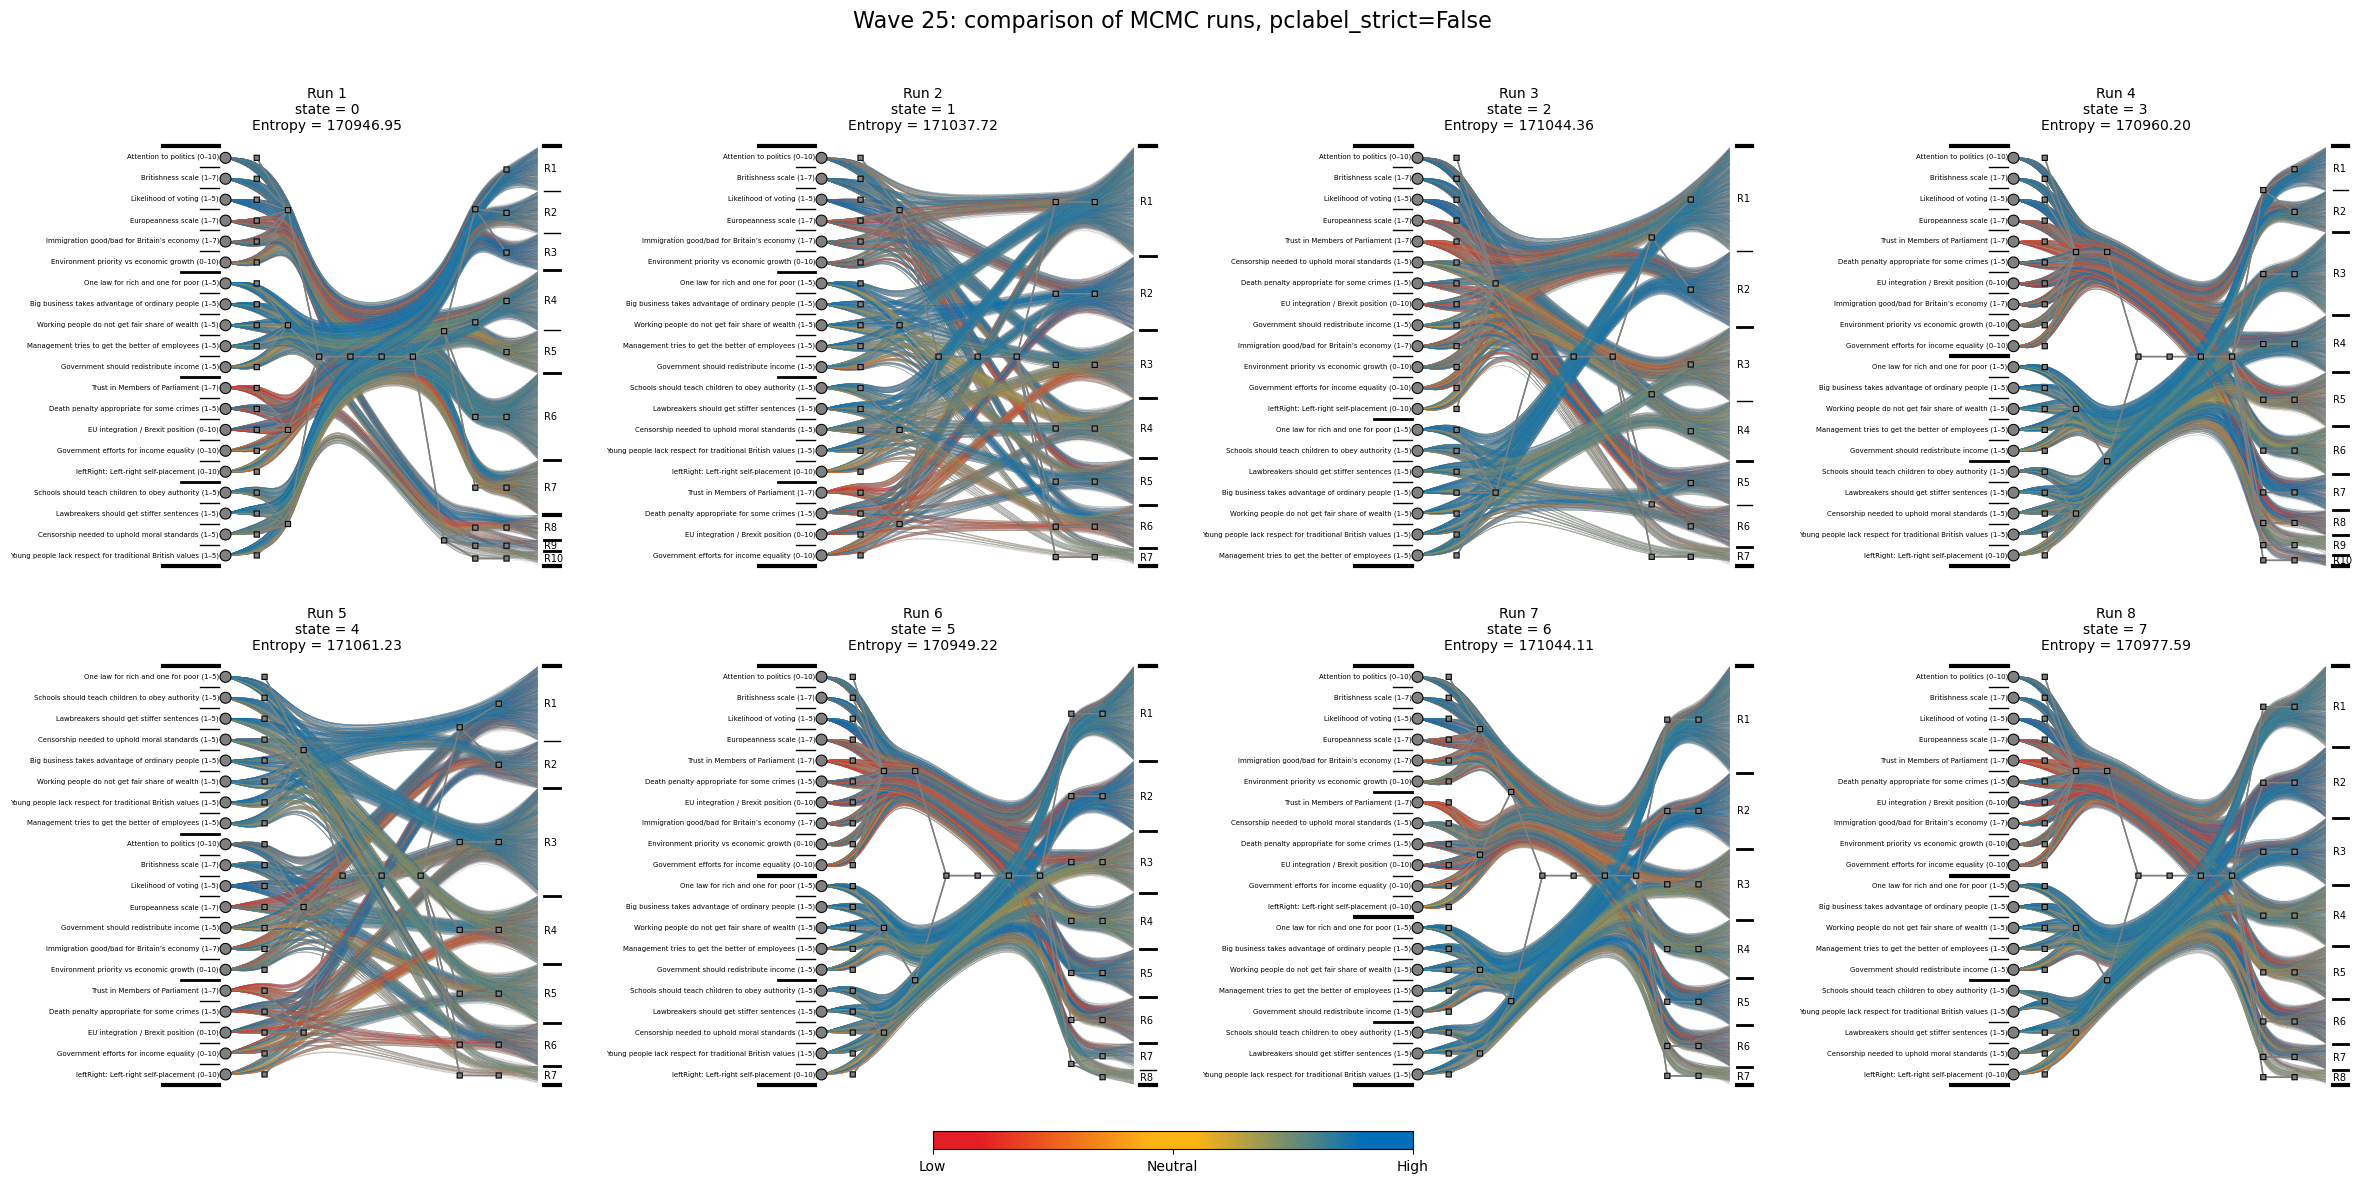

: 

In [ ]:
fig, axes = plot_all_SBM_network_runs(
    sbm_both=sbm_25_both,
    runs=runs_25_false,
    cmap=cmap,
    name_map=name_map,
    wave_label=25,
    scenario_label=False,
    ncols=4,
    figsize=(24, 12),
    save_path="wave25_false_21June.png",
    show_question_labels=True,
    show_respondent_labels=True)

## Gender

In [141]:
#W16_20_25_selected_columns[core_demographics + questions_by_wave["W16"] + questions_by_wave["W20"] + questions_by_wave["W25"]]

W16_20_25_selected_clean = W16_20_25_selected_columns[W16_20_25_selected_columns["gender"].isin(["Male", "Female"])]

#W16_20_25_selected_columns[core_demographics + questions_by_wave["W16"] + questions_by_wave["W20"] + questions_by_wave["W25"]]
pd.crosstab(
    W16_20_25_selected_clean["gender"],
    W16_20_25_selected_clean["leftRightW16"],
    normalize="index"
) * 100

leftRightW16,1,2,3,4,5,9999
gender,,,,,,
Male,9.101869,17.600964,21.458710,25.075347,11.934901,14.828210
Female,8.287057,15.249893,21.358394,18.368219,7.988039,28.748398


/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1583/1649043084.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop = (long_df .groupby(["wave", "gender", "leftRight"]).size().reset_index(name="count"))
/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1583/1649043084.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop["percent"] = (prop["count"] / prop.groupby(["wave", "gender"])["count"].transform("sum")* 100)


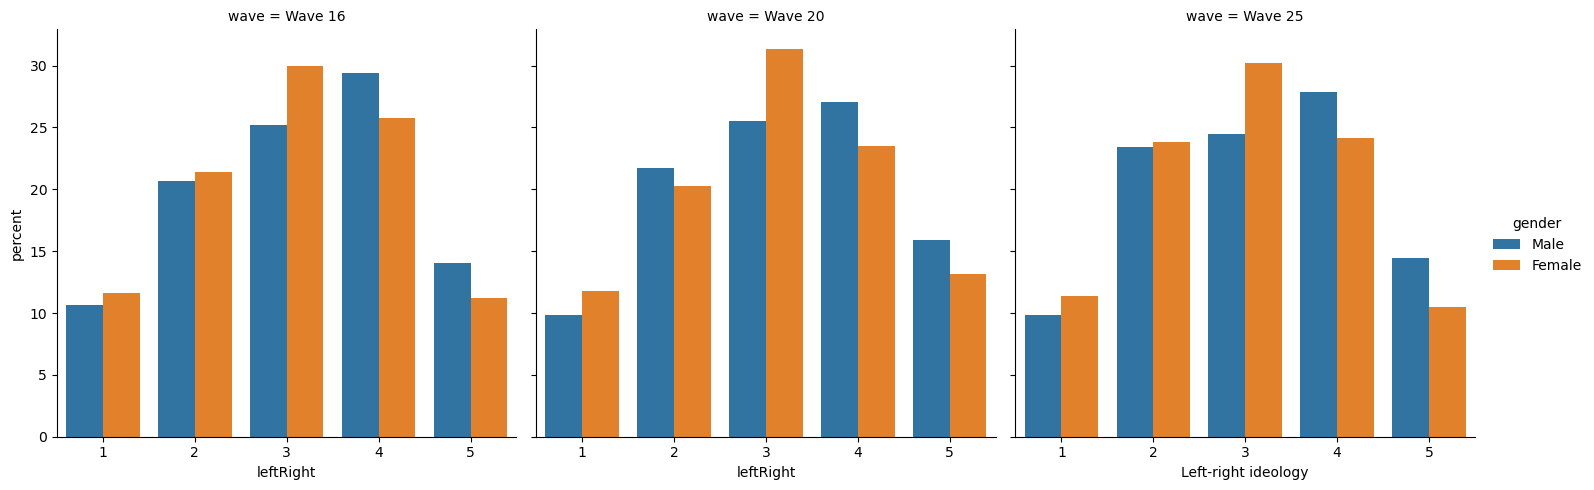

In [142]:
long_df = W16_20_25_selected_clean.melt(
    id_vars=["id", "gender"],
    value_vars=["leftRightW16", "leftRightW20", "leftRightW25"],
    var_name="wave",
    value_name="leftRight")

long_df = long_df[long_df["leftRight"] != 9999]
long_df = long_df[long_df["gender"].isin(["Male", "Female"])]

long_df["wave"] = long_df["wave"].replace({
    "leftRightW16": "Wave 16",
    "leftRightW20": "Wave 20",
    "leftRightW25": "Wave 25"})

prop = (long_df .groupby(["wave", "gender", "leftRight"]).size().reset_index(name="count"))

prop["percent"] = (prop["count"] / prop.groupby(["wave", "gender"])["count"].transform("sum")* 100)

sns.catplot(
    data=prop,
    x="leftRight",
    y="percent",
    hue="gender",
    col="wave",
    kind="bar")

plt.ylabel("Percent within gender")
plt.xlabel("Left-right ideology")
plt.show()

In [144]:
from scipy.stats import chi2_contingency

table_wave = pd.crosstab(long_df["wave"], long_df["leftRight"])
chi2, p, dof, expected = chi2_contingency(table_wave)

n = table_wave.to_numpy().sum()
r, c = table_wave.shape
cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print(table_wave)
print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Cramer's V: (How strong is that relationship between waves?)", cramers_v) # Its super small!!!!!

leftRight    1    2    3    4    5
wave                              
Wave 16    345  649  856  846  385
Wave 20    336  646  886  775  444
Wave 25    337  744  869  814  386
Chi-square: 17.601212481184614
p-value: 0.024423253692483
Degrees of freedom: 8
Cramer's V: (How strong is that relationship between waves?) 0.030732291366316982


In [145]:
table_gender = pd.crosstab(W16_20_25_selected_clean["gender"], W16_20_25_selected_clean["leftRightW16"])

chi2, p, dof, expected = chi2_contingency(table_gender)

n = table_gender.to_numpy().sum()
r, c = table_gender.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print("Chi-square:", chi2)
print("Cramer's V:", cramers_v)
print("p-value:", p)

Chi-square: 122.31373699416505
Cramer's V: 0.17486690438313723
p-value: 1.0151936734723334e-24


## Interest in Politics

/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1583/1586339233.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop = (long_df .groupby(["wave", "gender", "Intereseted_in_Politics"]).size().reset_index(name="count"))
/var/folders/jf/cwvy3hlj5tqfs022mxg95gj00000gn/T/ipykernel_1583/1586339233.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop["percent"] = (prop["count"] / prop.groupby(["wave", "gender"])["count"].transform("sum")* 100)


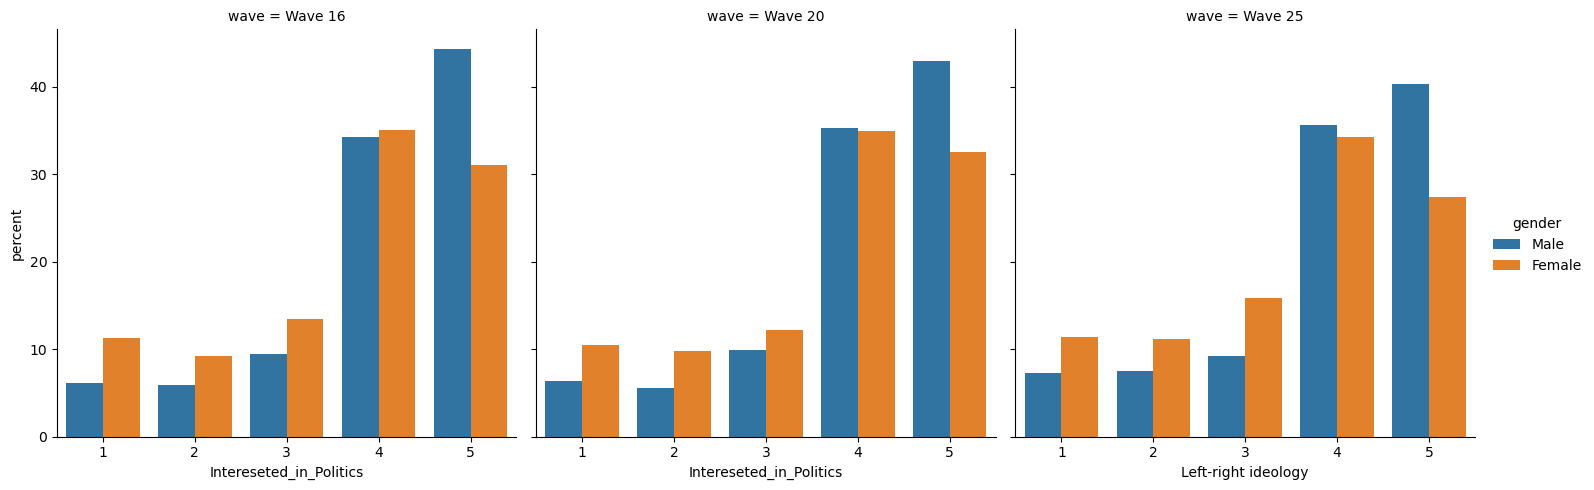

In [146]:
long_df = W16_20_25_selected_clean.melt(
    id_vars=["id", "gender"],
    value_vars=["polAttentionW16", "polAttentionW20", "polAttentionW25"],
    var_name="wave",
    value_name="Intereseted_in_Politics")

long_df = long_df[long_df["Intereseted_in_Politics"] != 9999]
long_df = long_df[long_df["gender"].isin(["Male", "Female"])]

long_df["wave"] = long_df["wave"].replace({
    "polAttentionW16": "Wave 16",
    "polAttentionW20": "Wave 20",
    "polAttentionW25": "Wave 25"})

prop = (long_df .groupby(["wave", "gender", "Intereseted_in_Politics"]).size().reset_index(name="count"))

prop["percent"] = (prop["count"] / prop.groupby(["wave", "gender"])["count"].transform("sum")* 100)

sns.catplot(
    data=prop,
    x="Intereseted_in_Politics",
    y="percent",
    hue="gender",
    col="wave",
    kind="bar")

plt.ylabel("Percent within gender")
plt.xlabel("Left-right ideology")
plt.show()

In [147]:
table_gender = pd.crosstab(W16_20_25_selected_clean["gender"], W16_20_25_selected_clean["polAttentionW25"])

chi2, p, dof, expected = chi2_contingency(table_gender)

n = table_gender.to_numpy().sum()
r, c = table_gender.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print("Chi-square:", chi2)
print("Cramer's V:", cramers_v)
print("p-value:", p)

Chi-square: 111.48936243591042
Cramer's V: 0.16695011413286787
p-value: 1.9846977601447663e-22
